# Class Project - Statistical Arbitrage in Cryptocurrencies

## Project Goal:

Statistical Arbitrage is a class of strategies that try to discover price volume patterns that predict returns.

We will find market inefficiencies using statistical arbitrage techinques.

# 1. Loading the Data
- Using Binance API to capture Price Data
- We will use the top 15 Crypto currencies by market cap/volume in anticipation of S&P DM50

In [ ]:
client = bnb_client(tld='US')

univ = get_top_binance_tickers() # Dynamically captures top 15 market-cap Crypto

# The below list is usually what is pulled from the data dynamically
# univ = ['ADAUSDT', 'AVAXUSDT', 'BNBUSDT', 'BTCUSDT', 'DASHUSDT', 'DOGEUSDT', 'ETHUSDT', 'HBARUSDT', 'HYPEUSDT',
         'LINKUSDT', 'SOLUSDT', 'SUIUSDT', 'USDCUSDT', 'XRPUSDT', 'ZECUSDT']

end_ts = '2026-03-26 02:12:22' # Defines UTC here for downstream use in the data itself as well as runtime log

freq = '4h'
px = {}
for x in univ:
    data = get_binance_px(x, freq, end_ts=end_ts)
    px[x] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px.columns = px.columns.str.removesuffix('USDT') # Remove USDT sufix from all coins for readability
tickers = list(px.columns)
tickers.sort() # Sort Tickers in alphabetical order
print(*tickers)
px = px.reindex(pd.date_range(px.index[0], px.index[-1], freq=freq))
px = px.ffill()
ret = px.pct_change()

ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC


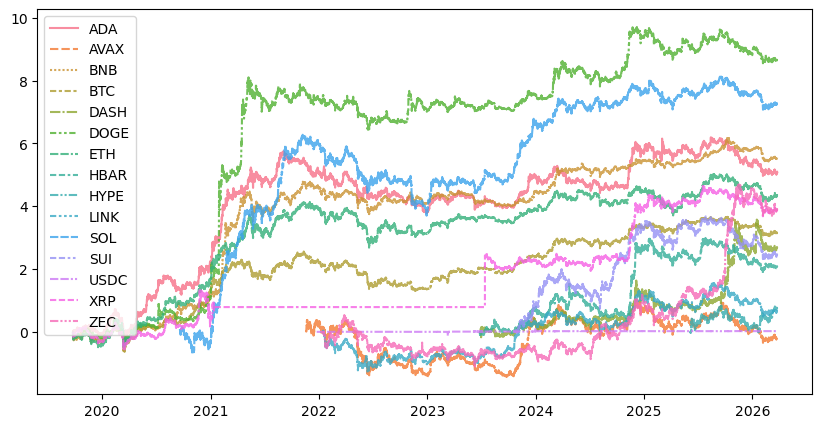

In [6]:
plt.figure(figsize=(10,5))
sns.lineplot(data=ret.cumsum(), linewidth=1.5, alpha=0.8)
plt.show()

# 2. Data Investigation
- Taking a look at Drawdowns for each ticker within our data
- Using Python Regression to identify unknown Beta **$\beta$** & Alpha **$\alpha$** values across coins
- Compare volatilities of residual returns to the original return for each coin
- Compare pairwise correlations across coins
- Compute the information ratio, & compare to the sharpe ratio for each coin

### Outlining Drawdown Details

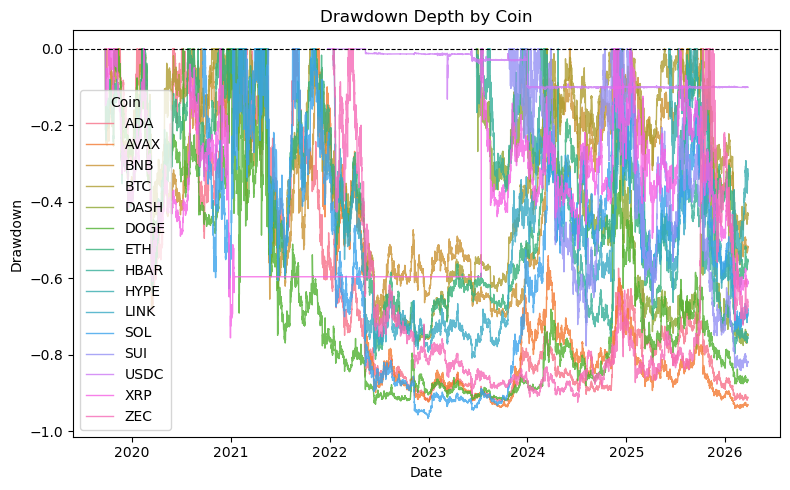

USDC   -0.132
HYPE   -0.654
BNB    -0.725
XRP    -0.756
BTC    -0.770
DASH   -0.785
HBAR   -0.797
LINK   -0.809
ETH    -0.812
SUI    -0.841
ADA    -0.922
ZEC    -0.924
DOGE   -0.929
AVAX   -0.940
SOL    -0.966
dtype: float64

In [7]:
dd = drawdown(px)
visualize_time_series(dd, 'Drawdown', 'Drawdown Depth by Coin')
dd.min().sort_values(ascending=False).round(3)

#### Observations
* USDC has the lowest max drawdown of -13%
* All other coins have a max drawdown of at least -65% roughly, up to nearly -97%

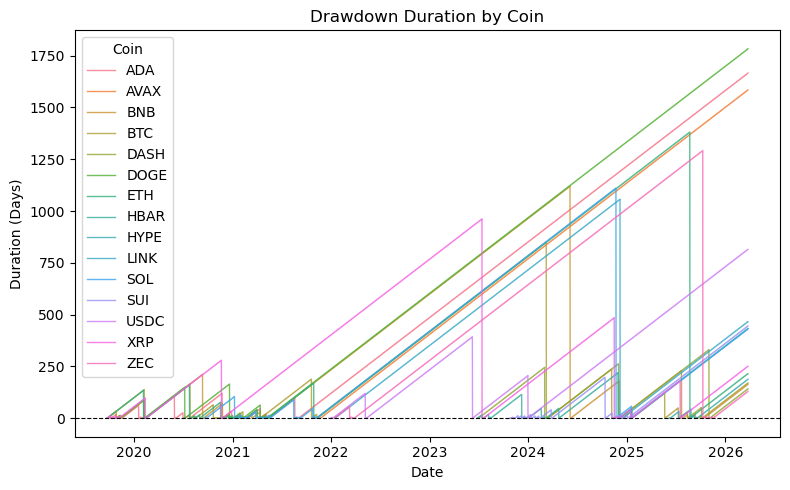

DOGE    1783
ADA     1666
AVAX    1584
ETH     1381
ZEC     1292
BNB     1120
SOL     1111
LINK    1057
XRP      962
BTC      850
USDC     815
SUI      445
HBAR     433
DASH     331
HYPE     188
dtype: Int64

In [8]:
ddd = dd_duration(px)
visualize_time_series(ddd, 'Duration (Days)', 'Drawdown Duration by Coin')
ddd.max().sort_values(ascending=False)

#### Observations
* Most coins have a drawdown duration of over a year, with the maximum being over 1760 days (nearly 5 years)

### Computing Beta **$\beta$** & Alpha **$\alpha$** with BTC as the Benchmark for Regression

In [9]:
# Computing β

corr = ret.rolling(365, min_periods=365).corr(ret['BTC']) # Rolling correlation with BTC
vol = ret.rolling(365, min_periods=365).std()             # Rolling volatility per asset
beta = (corr * vol).divide(vol['BTC'], axis=0)            # Rolling beta per asset

# Computing α

alpha = ret - beta.multiply(ret['BTC'], 0)

# Computing the volatilities of risidual returns to original returns

comp = {}
comp['original'] = ret.std() * np.sqrt(365)
comp['alpha'] = alpha.std() * np.sqrt(365)
comp = pd.DataFrame(comp).drop('BTC')
comp.sort_values(by='alpha', ascending=False).round(3)

,original,alpha
DASH,0.580,0.542
ZEC,0.523,0.481
DOGE,0.533,0.459
XRP,0.386,0.443
HYPE,0.510,0.410
SUI,0.485,0.379
SOL,0.483,0.364
HBAR,0.430,0.343
ADA,0.400,0.291
AVAX,0.404,0.277


In [10]:
# Taking a look at the mean values of β
beta.mean().sort_values().round(3)

USDC    0.007
BNB     0.878
XRP     0.966
DASH    0.975
ZEC     0.977
BTC     1.000
ETH     1.102
DOGE    1.171
ADA     1.187
LINK    1.277
HBAR    1.326
SOL     1.348
HYPE    1.352
AVAX    1.384
SUI     1.471
dtype: float64

#### Observations
- Isolating Beta **$\beta$** reveals the market sensitivity of each coin in the data
- Many coins have a mean **$\beta$** value > 1 which suggests high volatility relative to BTC
- USDC, DASH and other coins with **$\beta$** < 1 are less impacted by BTC activity per beta, yet not all of them have high Alpha **$\alpha$** values
    - DASH, XRP, & ZEC each have **$\beta$** values below 1 & **$\alpha$** above 0.4
- XRP, DASH & USDC have higher alpha volatility than their original volatility with BTC component included. This suggests their returns could be negatively correlated to BTC

### Computing Pairwise Correlations Between Each Crypto

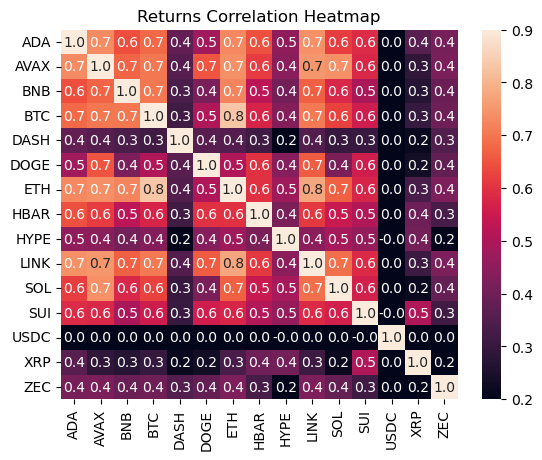

In [11]:
ret_corr_mtx = ret.corr()

sns.heatmap(ret_corr_mtx, annot=True, fmt =".1f", vmin=0.2, vmax=0.9)
plt.title('Returns Correlation Heatmap')
plt.show()

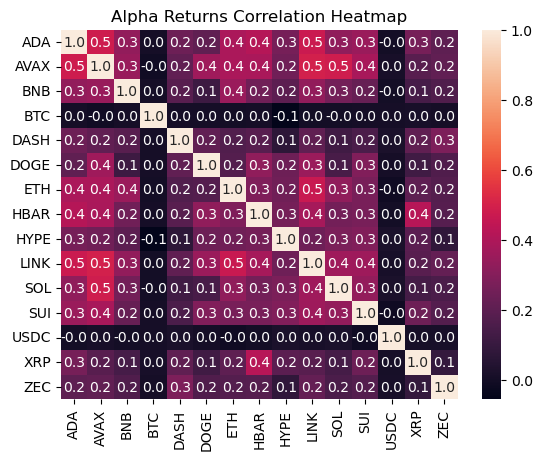

In [12]:
alpha_corr_mtx = alpha.corr()

sns.heatmap(alpha_corr_mtx, annot=True, fmt =".1f")
plt.title('Alpha Returns Correlation Heatmap')
plt.show()

#### Computing Sharpe & Information Ratios for Each Crypto

In [13]:
# Information Ratio vs Sharpe Ratio
sr_ir = {}
sr_ir['sharpe ratio'] = ret.mean(skipna=True) / ret.std(skipna=True)*np.sqrt(365)
sr_ir['information ratio'] = alpha.mean(skipna=True) / alpha.std(skipna=True)*np.sqrt(365)
sr_ir = pd.DataFrame(sr_ir)

# Explicitly set BTC's information ratio to NaN as it is the benchmark
sr_ir.loc['BTC', 'information ratio'] = np.nan

sr_ir.sort_values(by='information ratio', ascending=False).round(3)

,sharpe ratio,information ratio
HYPE,0.304,0.652
SOL,0.455,0.387
BNB,0.437,0.366
DOGE,0.421,0.331
ZEC,0.294,0.303
DASH,0.281,0.297
ETH,0.347,0.196
ADA,0.325,0.168
XRP,0.256,0.148
SUI,0.348,0.140


#### Observations
- Without influence from BTC, HYPE seems to have a decent sharpe improvement, whereas majority of other coins are very much volatile on their own without market influence

# 3. Signal Generation: Finding Momentum & Reversal Strategies

#### Cross Sectional (XS): Which coins are stronger or weaker than eachother right now?
- “Rank all coins by volume → go long the top quartile, short the bottom quartile”
- Alpha Returns show much lower correlations accros the board.


#### Time Series (TS): Are coins trending up or down relative to their own history?
- “This coin’s volume is high relative to its own history → go long this coin”
- Most coins are highly correlated with eachother and BTC.

**Momentum:**
- Time Horizon (TS)
- Seasonality (TS)

**Reversal:**
- Correlation Pairs (XS)
- Correlation Baskets (XS)

### Momentum: Time Horizon (TS Strategy)

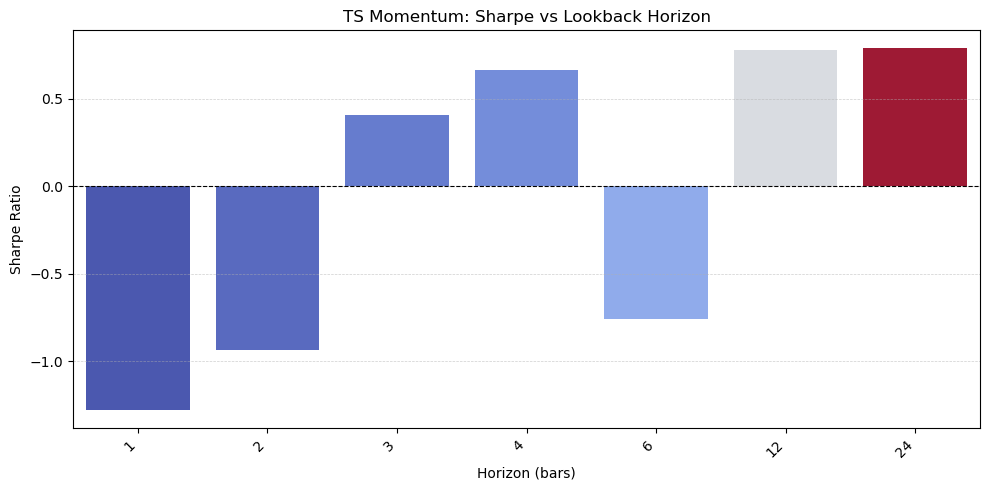

In [14]:
horizons = [1, 2, 3, 4, 6 , 12, 24]
results = {}
th_returns = {}

for h in horizons:
  signal = ret.rolling(h, min_periods=1).mean() # Calculates Avg Return
  signal = signal.divide(signal.abs(), fill_value=0) # +1 if trending up, -1 if down for each coin's independent signal

  strat_ret = (signal.shift(1) * ret).mean(axis=1) # Average across coins (equal weight)
  th_returns[f'h_{h}'] = strat_ret
  results[h] = strat_ret.mean() / strat_ret.std() * ann # Annualize for hourly

th_df = pd.Series(results).reset_index()
th_df.columns = ['Horizon (bars)', 'Sharpe Ratio']

visualize(th_df, th_df.columns[0], th_df.columns[1],
          'coolwarm', 'TS Momentum: Sharpe vs Lookback Horizon')

#### Observations
- Horizons with Negative Sharpe: 1, 2, 6
- Clear crossover doesn't happen until 12 & 24 horizons
- Sharpe rises until 4 horizons, sharply declines around 6 horizons, ans gradually increases from then on
- There can be little to no edge at 3 horizons
- Short term momentum for the coins will be negative mostly but it reverses at longer periods after 6 horizons

In [15]:
# Capturing returns from this signal
th_df = pd.DataFrame(th_returns).dropna() # rows=time, cols=horizons 1 thru 24
th_df.sample(3).round(4)

,h_1,h_2,h_3,h_4,h_6,h_12,h_24
2024-04-05 12:00:00+00:00,-0.0225,-0.0241,-0.0241,-0.0241,-0.0205,-0.0188,-0.0241
2023-09-22 08:00:00+00:00,-0.0015,0.0030,-0.0028,-0.0043,-0.0037,0.0004,0.0022
2024-12-01 08:00:00+00:00,0.0026,-0.0012,-0.0017,0.0013,0.0120,0.0176,0.0184


### Momentum: Seasonality (TS Strategy)

In [16]:
# Weekday vs Weekend Returns
is_weekday = pd.Series(ret.index.dayofweek < 5, index=ret.index)

# Signal: for each coin, what's the avg return on weekdays vs weekends?
weekday_mean = ret[is_weekday].mean()   # Avg returns on weekdays
weekend_mean = ret[~is_weekday].mean()  # Avg return on weekends

# Go long on coins that historically trend up on weekdays, during weekdays
week_df = pd.DataFrame(0.0, index=ret.index, columns=ret.columns)
week_df[is_weekday] = np.sign(weekday_mean)   # Each coin's weekday direction
week_df[~is_weekday] = np.sign(weekend_mean)  # Each coin's weekend direction

weekly_strat_ret = (week_df.shift(1) * ret).mean(axis=1)
print('Weekday Sharpe:', round((strat_ret[is_weekday].mean() / strat_ret[is_weekday].std() * ann), 3))
print('Weekend Sharpe:', round((strat_ret[~is_weekday].mean() / strat_ret[~is_weekday].std() * ann), 3))

weekday_ret = weekly_strat_ret.where(is_weekday)   # NaN on weekend rows
weekend_ret = weekly_strat_ret.where(~is_weekday)  # NaN on weekday rows

Weekday Sharpe: 0.75
Weekend Sharpe: 0.918


#### Observations
- Weekend sharpes is notably higher than weekday sharpes
- Week-long seasonality is likely stable for crypto in general, but weekend peformance is better

In [17]:
# Capturing returns from this signal
week_df = pd.DataFrame({'weekday': weekday_ret}).dropna()
weekend_df = pd.DataFrame({'weekend': weekend_ret}).dropna()
week_df.sample(3).round(4)

,weekday
2023-03-21 16:00:00+00:00,0.0027
2020-07-07 08:00:00+00:00,0.0020
2020-11-23 00:00:00+00:00,0.0195


In [18]:
weekend_df.sample(3).round(4)

,weekend
2020-05-10 12:00:00+00:00,-0.0141
2023-10-29 04:00:00+00:00,0.0054
2022-06-18 16:00:00+00:00,-0.0420


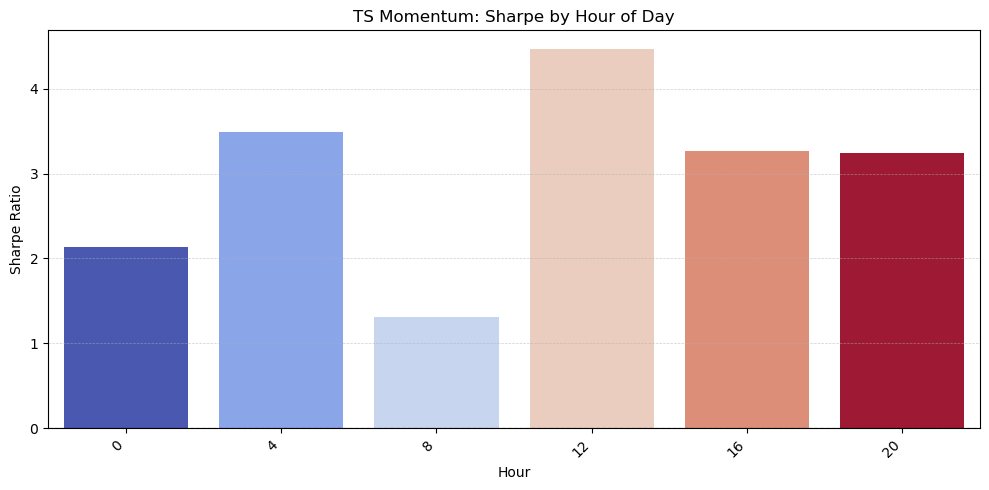

In [19]:
# Hour of Day Returns
hour_sharpes = {}
hour_returns = {}
for h in range(0, 24, 4): # 4h bars only land on 0, 4, 8, 12, 16, 20
    mask = ret.index.hour == h
    hour_mean = ret[mask].mean()   # A coin's average return at a given hour
    signal_h = np.sign(hour_mean)  # TS: Capturing each coin's own tendency
    strat_h =  (signal_h * ret[mask]).mean(axis=1)
    hour_returns[f'h{h:02d}'] = strat_h.reindex(ret.index) # save timeseries, NaN outside this hour
    hour_sharpes[h] = strat_h.mean() / strat_h.std() * ann

hour_df = pd.Series(hour_sharpes).reset_index()
hour_df.columns = ['Hour', 'Sharpe Ratio']

visualize(hour_df, hour_df.columns[0], hour_df.columns[1],
          'coolwarm', 'TS Momentum: Sharpe by Hour of Day')

hour_df = pd.DataFrame(hour_returns)  # rows=time, cols=h00, h04, h08...

#### Observations
- The second half of the day in UTC show stronger sharpes
- Asian session (0-8 UTC) loses steam between 4 & 8 Hours
- EU session (8 UTC+) has brings sharpes back up to above 3.0
- US session consistently maintains saharpe above 3.0
- Its probably best to trade during the hours of 12 pm UTC, until 8pm or overnight. The middle of the Asian session at 4am UTC is also good

In [20]:
# Capturing Returns from this signal - working around nulls
hour_dfs = {f'hour_{col}': pd.DataFrame({col: series}).dropna()
            for col, series in hour_returns.items()}

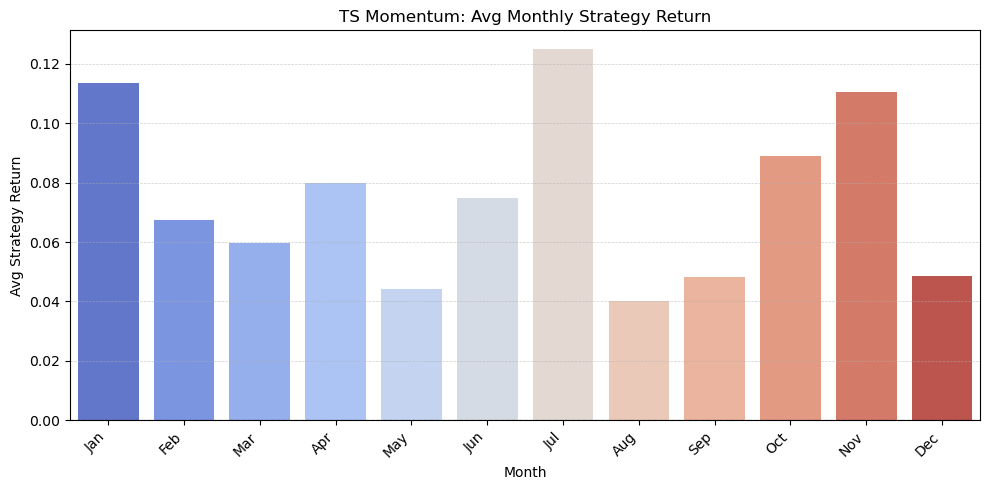

In [21]:
# Returns by Month
monthly_ret = ret.resample('ME').sum() # Resample timeseries data into monthly intervals
month_avg = monthly_ret.groupby(monthly_ret.index.month).mean() # per coin month avg

# Signal: in month m, go long/short on each coin based on its own historical tendencies
monthly_signal = np.sign(month_avg) # Shape: 12, n_coins

monthly_strat = []
monthly_coin_returns = {}
for month, grp in monthly_ret.groupby(monthly_ret.index.month): # Iterate through each month & find the groups
    sig = monthly_signal.loc[month] # Retrieves the signal for each month
    r = (sig * grp).mean(axis=1)    # Multiply signal by monthly returns, grabbing the average for each row
                                    # Simulates an equal-weighted strategy following historical monthly tendency
    monthly_strat.append(r)

monthly_strat = pd.concat(monthly_strat).sort_index()
month_df = monthly_strat.groupby(monthly_strat.index.month).mean().reset_index()
month_df.columns = ['Month', 'Avg Strategy Return']
month_df['Month'] = month_df['Month'].map(
    {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
     7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
     })

visualize(month_df, month_df.columns[0], month_df.columns[1],
          'coolwarm', 'TS Momentum: Avg Monthly Strategy Return')

#### Observations
- #### The best months for returns above 10%: January, July, November
- The worst returns: Mid & Late Q3 & Mid Q2
- Q1 overall has the best average returns
- All months, however, show some returns

In [22]:
# Strategy returns timeseries — one col per coin
for coin in ret.columns:
    coin_strat = []
    for month, grp in monthly_ret.groupby(monthly_ret.index.month):
        sig = monthly_signal.loc[month, coin]
        coin_strat.append(sig * grp[coin])
    monthly_coin_returns[coin] = pd.concat(coin_strat).sort_index()

month_df = pd.DataFrame(monthly_coin_returns).dropna()
month_df.sample(3).round(4)

,ADA,AVAX,BNB,BTC,DASH,DOGE,ETH,HBAR,HYPE,LINK,SOL,SUI,USDC,XRP,ZEC
2025-03-31 00:00:00+00:00,0.1542,-0.1205,0.0357,-0.0059,-0.1213,-0.1572,-0.1717,0.2211,0.0,-0.0423,-0.1290,-0.1711,0.0000,-0.0202,0.0776
2022-06-30 00:00:00+00:00,0.2481,0.3458,0.3442,0.4324,-0.0000,0.1973,0.5302,-0.0000,0.0,0.1063,0.1963,-0.0000,0.0003,-0.0000,0.4751
2023-05-31 00:00:00+00:00,-0.0468,0.1828,0.0919,0.0662,-0.0000,-0.0979,0.0073,0.0000,0.0,0.0735,0.0769,-0.0000,0.0001,0.0000,-0.1442


### Reversal: Correlation Pairs (XS)

In [23]:
# Find highly correlated pairs of coins
corr_matrix = ret.rolling(168).corr().iloc[-ret.shape[1]:]  # Last window
corr_matrix = corr_matrix.droplevel(level=0) # Drop the timestamp level from the index

# Get all pairs with correlation above threshold of 0.7
thresh  = 0.7
pairs   = []
for i, a in enumerate(ret.columns):
    for j, b in enumerate(ret.columns):
        if j <= i:
            continue
        # Ensure both assets are in the current corr_matrix before trying to access
        if a in corr_matrix.index and b in corr_matrix.columns:
            c = corr_matrix.loc[a, b]
            if not np.isnan(c) and c > thresh:
                pairs.append((a, b, c))

pairs_df = pd.DataFrame(pairs, columns=['asset_a', 'asset_b', 'corr'])

   asset_a asset_b   corr
42     ETH    LINK  0.933
28     BTC     ETH  0.922
43     ETH     SOL  0.908
19     BNB     BTC  0.894
30     BTC    LINK  0.883
51    LINK     SOL  0.881
21     BNB     ETH  0.872
24     BNB     SOL  0.871
45     ETH     XRP  0.870
53    LINK     XRP  0.866
23     BNB    LINK  0.861
31     BTC     SOL  0.857
8      ADA     SUI  0.856
52    LINK     SUI  0.852
55     SOL     XRP  0.850
44     ETH     SUI  0.849
9      ADA     XRP  0.837
40    DOGE     XRP  0.835
3      ADA    DOGE  0.835
33     BTC     XRP  0.832
32     BTC     SUI  0.829
54     SOL     SUI  0.826
0      ADA    AVAX  0.825
6      ADA    LINK  0.823
56     SUI     XRP  0.823
17    AVAX     SUI  0.816
13    AVAX     ETH  0.815
35    DOGE     ETH  0.815
39    DOGE     SUI  0.814
37    DOGE    LINK  0.813
15    AVAX    LINK  0.813
4      ADA     ETH  0.811
38    DOGE     SOL  0.806
7      ADA     SOL  0.801
18    AVAX     XRP  0.798
25     BNB     SUI  0.794
26     BNB     XRP  0.786
16    AVAX  

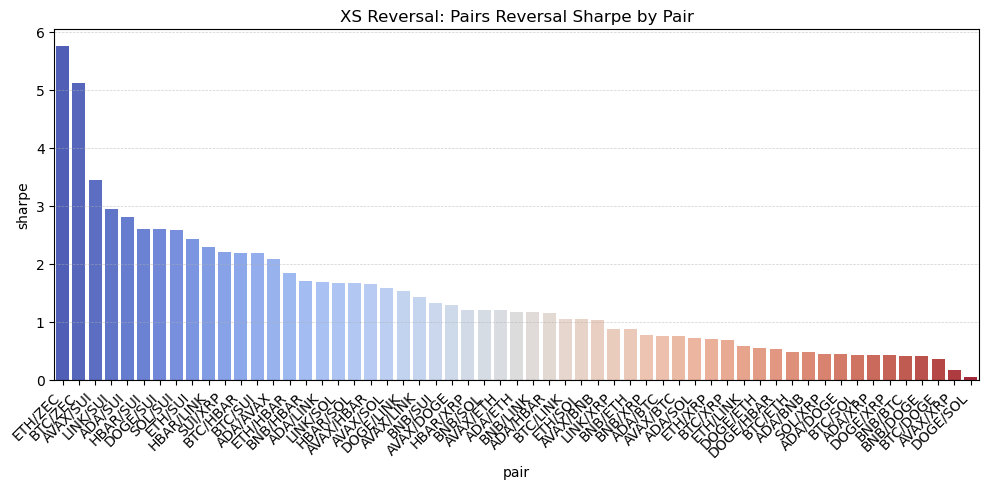

In [24]:
# Pairs Reversal
pair_rev = []
pair_returns = {}

for _, row in pairs_df.iterrows(): # Generates an iterator on the pairs dataframe. Ignores the index with '_'
    a, b = row['asset_a'], row['asset_b']
    strat = pairs_reversal(ret, a, b) # Grabs returns based on the pairs identified
    pair_name = f'{a}/{b}' # Captures name pairs
    pair_returns[pair_name] = strat # save timeseries with name pairs as columns
    sr = strat.mean() / strat.std() * ann
    pair_rev.append({'pair': f'{a}/{b}', 'corr': row['corr'], 'sharpe': sr})

pair_rev = pd.DataFrame(pair_rev).set_index('pair').sort_values('sharpe', ascending=False)

pd.set_option('display.max_rows', None) # displays full output from pairs_df
print(pairs_df.sort_values('corr', ascending=False).round(3))
visualize(pair_rev[pair_rev['sharpe'] > 0].reset_index(), 'pair', 'sharpe',
          'coolwarm', 'XS Reversal: Pairs Reversal Sharpe by Pair') # Only visualize coin pairs with Sharpes above 0

#### Observations
- Positive Sharpes say the pair strategy is effectively profiting from reversal back to their historical relationship. Sharpes > 1 have good performance
- Highest pair correlation: ETH/Link (> 0.9). Reversal Sharpe <1
- Highest Sharpe: ETH/ZEC (>5.0). Pairs correlation is ~0.73
- Perhaps highly correlated pairs dont result in higher reversal sharpes
- **SUI appears to be present in many high performing correlation pairs**

In [25]:
# Strategy returns timeseries
pair_rev = pd.DataFrame(pair_returns).dropna()  # rows=time, cols=pairs e.g. BTC/ETH
pair_rev.sample(3)

,ADA/AVAX,ADA/BNB,ADA/BTC,ADA/DOGE,ADA/ETH,ADA/HBAR,ADA/LINK,ADA/SOL,ADA/SUI,ADA/XRP,...,HBAR/LINK,HBAR/SOL,HBAR/SUI,HBAR/XRP,LINK/SOL,LINK/SUI,LINK/XRP,SOL/SUI,SOL/XRP,SUI/XRP
2025-06-01 08:00:00+00:00,-0.000000,-0.0,-0.000000,-0.005116,-0.0,-0.002749,-0.0,-0.000000,0.000000,-0.000000,...,-0.0,-0.0,0.000000,0.001261,-0.000000,0.000000,-0.000000,0.000000,-0.0,0.000000
2025-02-23 20:00:00+00:00,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.001151,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2025-12-29 08:00:00+00:00,0.002737,-0.0,0.004436,0.001632,-0.0,-0.000000,-0.0,0.004442,0.006377,0.001408,...,-0.0,-0.0,0.003912,-0.000000,0.003891,0.005827,0.000857,0.001936,-0.0,0.004969


### Reversal: Correlation Baskets (XS)

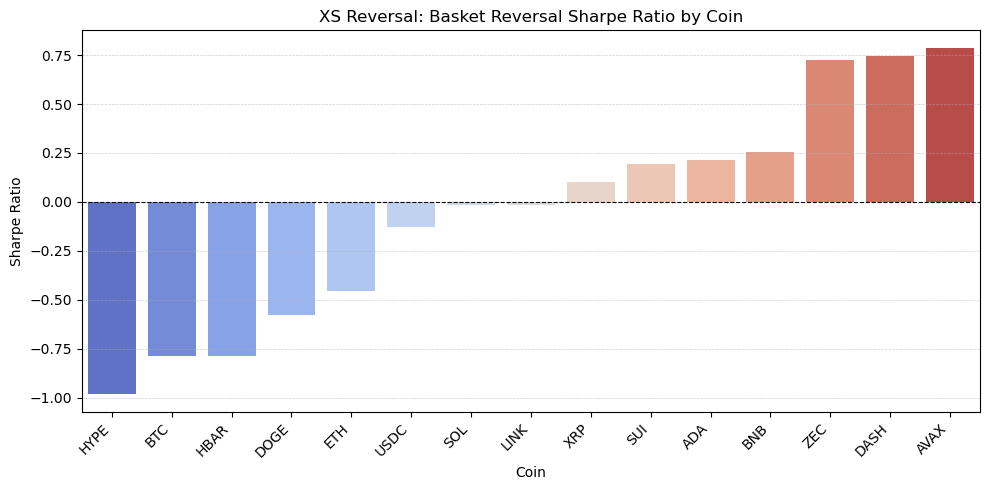

In [26]:
# Correlated Basket Reversal
# Regress asset against its sector basket; trade the residual
basket_results = {}
basket_returns = {}

for asset in ret.columns:
    basket = [c for c in ret.columns if c!= asset] # Ensures an asset is being regressed in a bucket against all other assets
    strat = basket_reversal(ret, asset, basket) # Grab strategy returns of each asset in a bucket
    basket_returns[asset] = strat # save timeseries
    basket_results[asset] = strat.mean() / strat.std() * ann

basket_df = pd.Series(basket_results).sort_values().sort_values().reset_index()
basket_df.columns = ['Coin', 'Sharpe Ratio']

visualize(basket_df, basket_df.columns[0], basket_df.columns[1],
          'coolwarm', 'XS Reversal: Basket Reversal Sharpe Ratio by Coin')

#### Observations
- AVAX has the highest Basket Reversal sharpe, > 0.5
- HYPE has the lowest Basket Reversal sharpe, at ~ -1
- Though USDC & PAXG had low correlations with other coins in the heatmap, PAXG has decent sharpe here while USDC has a negative sharpe
- It's a bit of a mixed bag as coins with lower alpha volatilites dont necessarily all have lower sharpes here. Doge for example has an above average alpha volatiltiy, yet has a negative sharpe here.
- Unline Correlation Pairs, SUI isn't a top performer here in Correlation Basket Reversal

In [27]:
# Strategy returns timeseries
basket_df = pd.DataFrame(basket_returns).dropna() # rows=time, cols=coins
basket_df.sample(3)

,ADA,AVAX,BNB,BTC,DASH,DOGE,ETH,HBAR,HYPE,LINK,SOL,SUI,USDC,XRP,ZEC
2026-01-16 20:00:00+00:00,0.020361,0.017177,0.006781,0.005944,0.015039,0.008243,0.006459,0.020098,-0.005587,0.012528,0.005691,0.013630,-0.000200,0.006464,-0.007976
2026-02-12 16:00:00+00:00,0.004937,-0.008959,0.000805,0.019629,0.035869,-0.013715,-0.010317,0.025506,0.019218,-0.003567,-0.033666,0.000762,0.000600,0.009717,-0.022015
2025-10-21 08:00:00+00:00,-0.000933,-0.019878,0.002420,0.004216,0.057137,-0.000875,0.003795,-0.007539,-0.001111,0.003330,0.009205,0.004796,-0.001502,-0.001606,-0.073974


# 4. Weighting & Performance Evaluation

Current Signsls

TS:
- th_df
- week_df
- weekend_df
- hour_df
- month_df

XS:
- pair_rev
- basket_df

In [28]:
# Capturing signals into a dictionary
signals = {
    'time horizon': th_df,
    'week': week_df,
    'weekend': weekend_df,
    **hour_dfs,
    'month': month_df,
    'pair_rev': pair_rev,
    'basket': basket_df
}

### Find Historical Average Return $\mu$, Covariance Matrix $\Sigma$, and Correlation Matrix:

### Historical Average Return $\mu$

mu = ret.mean() # Historical Average Return
mu

### Covariance Matrix $\Sigma$

sigma = ret.cov() # Covariance Matrix
sigma

### Correlation Matrix $\rho$

corr = ret.corr() # Correlations | "Normalized version of Covariance Matrix" <br>
corr.round(2)

In [29]:
# Dictionaries to store results

mu_dict = {}
sigma_dict = {}
corr_dict = {}

In [30]:
weights = {}
for name, df in signals.items():
    # Compute Historical Average Return, Covariance Matrix, and Correlation Matrix with unique names for each signal
    mu_dict[f'{name}_mu'] = df.mean()
    sigma_dict[f'{name}_sigma'] = df.cov()
    corr_dict[f'{name}_corr'] = df.corr()

    # Compute weights
    mu = mu_dict[f'{name}_mu']
    sigma = sigma_dict[f'{name}_sigma']

    weights[f'{name}_optimal'] = optimal_weights(sigma,mu)
    weights[f'{name}_eqvol_weights'] = eqvol_weights(sigma)
    weights[f'{name}_sr_weights'] = sr_weights(sigma,mu)

    # print results per signal
    print(f'\n------------------------------ {name} ------------------------------')
    print('\nOptimal Weights:\n', weights[f'{name}_optimal'])
    print('\nEqVol Weights:\n', weights[f'{name}_eqvol_weights'])
    print('\nSR Weights:\n', weights[f'{name}_sr_weights'])


------------------------------ time horizon ------------------------------

Optimal Weights:
 [-0.12399981 -0.12320134  0.10770027  0.19025197 -0.27009787  0.1313464
  0.05340233]

EqVol Weights:
 [0.14323395 0.14511632 0.1438203  0.14305386 0.14142967 0.14194974
 0.14139616]

SR Weights:
 h_1    -0.231917
h_2    -0.167024
h_3     0.071503
h_4     0.115625
h_6    -0.139379
h_12    0.136770
h_24    0.137782
dtype: float64

------------------------------ week ------------------------------

Optimal Weights:
 [1.]

EqVol Weights:
 [1.]

SR Weights:
 weekday    1.0
dtype: float64

------------------------------ weekend ------------------------------

Optimal Weights:
 [1.]

EqVol Weights:
 [1.]

SR Weights:
 weekend    1.0
dtype: float64

------------------------------ hour_h00 ------------------------------

Optimal Weights:
 [1.]

EqVol Weights:
 [1.]

SR Weights:
 h00    1.0
dtype: float64

------------------------------ hour_h04 ------------------------------

Optimal Weights:
 [1.]



#### Observations
* For signal weights, we can drop the week, weekend, & 6 horizon (24h) returns as they are not multi-asset returns. Thus, the weights are not doing anything interesting.
* USDC might be heavily skewing results as it is a stable coin with near-zero volatility. Results in artificially high skarpe ratio and tiny variance.

## Recapturing Returns without USDC & Recapturing strategy returns from relevant signals
#### The data from here on out will be using full 1D time bars rather than 4h time bars
<br> Code cell is hidden to reduce clutter.

In [31]:
ret = ret.drop('USDC', axis=1)
ret = ret.resample('D').sum() # Resample to daily for portfolio construction

# Signal Generation

# Time Horizons -------------------------------------------------------------------------
th_returns = {}
th_signals = {}
horizons = [1, 2, 3, 5, 7, 10, 14, 21, 28, 30]  # daily bars

for h in horizons:
    signal = ret.rolling(h, min_periods=1).mean() # Calculates Avg Return
    signal = signal.divide(signal.abs(), fill_value=0) # +1 if trending up, -1 if down for each coin's independent signal

    strat_ret = (signal.shift(1) * ret).mean(axis=1) # Average across coins (equal weight)
    th_returns[f'h_{h}'] = strat_ret
    th_signals[f'h_{h}'] = signal # Capturing signal returns per asset

# Strategy returns timeseries
th_df = pd.DataFrame(th_returns).dropna() # rows=time, cols=horizons 1 thru 30

# Correlation Pairs ------------------------------------------------------------------------
# Find highly correlated pairs of coins
corr_matrix = ret.rolling(28).corr().iloc[-ret.shape[1]:]  # Last window
corr_matrix = corr_matrix.droplevel(level=0) # Drop the timestamp level from the index

# Get all pairs with correlation above threshold of 0.7
thresh  = 0.7
pairs   = []
for i, a in enumerate(ret.columns):
    for j, b in enumerate(ret.columns):
        if j <= i:
            continue
        # Ensure both assets are in the current corr_matrix before trying to access
        if a in corr_matrix.index and b in corr_matrix.columns:
            c = corr_matrix.loc[a, b]
            if not np.isnan(c) and c > thresh:
                pairs.append((a, b, c))

pairs_df = pd.DataFrame(pairs, columns=['asset_a', 'asset_b', 'corr'])
pair_returns = {}

for _, row in pairs_df.iterrows(): # Generates an iterator on the pairs dataframe. Ignores the index with '_'
    a, b = row['asset_a'], row['asset_b']
    strat = pairs_reversal(ret, a, b, lookback=4) # Grabs returns based on the pairs identified. 4 days ≈ 96h
    pair_name = f'{a}/{b}' # Captures name pairs
    pair_returns[pair_name] = strat # save timeseries with name pairs as columns

# Strategy returns timeseries
pair_rev = pd.DataFrame(pair_returns).dropna()  # rows=time, cols=pairs e.g. BTC/ETH
pair_rev = pair_rev.mean(axis=1)

# Correlated Baskets -----------------------------------------------------------------------
basket_returns = {}

for asset in ret.columns:
    basket = [c for c in ret.columns if c!= asset] # Ensures an asset is being regressed in a bucket against all other assets
    strat = basket_reversal(ret, asset, basket, lookback=28) # Grab strategy returns of each asset in a bucket. 28 day Lookback
    basket_returns[asset] = strat # save timeseries

# Strategy returns timeseries
basket_df = pd.DataFrame(basket_returns).dropna() # rows=time, cols=coins
basket_df = basket_df.mean(axis=1) # Ensures
print("Signal regenration is complete!")

Signal regenration is complete!


### Current Signsls

TS:
- th_df - we are discounting monthly returns as standalone research. We're using Time Horizon only for TS

XS:
- pair_rev
- basket_df

Optimal Weights:
 [-0.14272901  0.01589573  0.14857998 -0.10490503  0.04515638  0.00433645
  0.15445324 -0.1738157   0.20762509 -0.00250338]

EqVol Weights:
 [0.10203424 0.09978155 0.09964027 0.09696783 0.09784651 0.09898251
 0.09923029 0.10256211 0.10178832 0.10116636]

SR Weights:
 h_1    -0.039626
h_2     0.058601
h_3     0.090768
h_5     0.073778
h_7     0.093159
h_10    0.106661
h_14    0.130764
h_21    0.107780
h_28    0.152409
h_30    0.146454
dtype: float64


<Axes: >

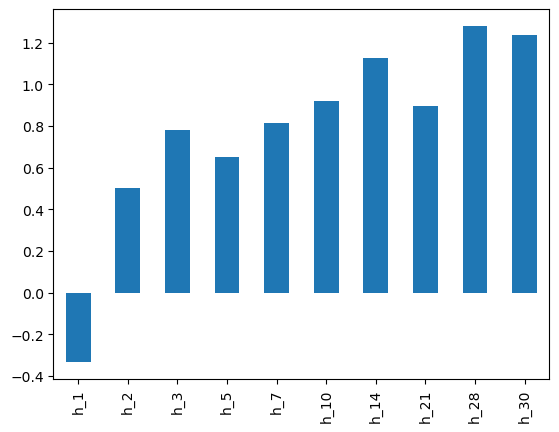

In [32]:
# Momentum (TS) | Time Horizon
th_mu = th_df.mean()
th_sigma = th_df.cov() # Covariance Matrix sigma
th_corr = th_df.corr().round(2)

th_stats = pd.DataFrame({
    'ret': th_mu,
    'vol': np.sqrt(np.diag(th_sigma)),
    'sr': th_mu / np.sqrt(np.diag(th_sigma))
})

print('Optimal Weights:\n', optimal_weights(th_sigma,th_mu))
print('\nEqVol Weights:\n', eqvol_weights(th_sigma))
print('\nSR Weights:\n', sr_weights(th_sigma,th_mu))
th_sr = th_df.mean()/th_df.std()*np.sqrt(365)
th_sr.plot(kind='bar')

#### Observations
* We are going with SR Weights because we are prioritizing risk-adjusted returns as Crypto is very volatile
* It seeams the Sharpe peaks at 28 days

## Find Optimal Weighting Methodology for the Data:

### TS Portfolio — time horizon only
#### Monthly seasonality excluded from portfolio construction (frequency incompatibility)
#### Retained as standalone research finding in Section 3

In [33]:
# Prevent Look-ahead Bias by subsetting the data
th_train_end = int(len(th_df) * 0.70)
th_mu_train    = th_df.iloc[:th_train_end].mean()
th_sigma_train = th_df.iloc[:th_train_end].cov()

# Create portfolio without look-ahead bias
th_wgts = sr_weights(th_sigma_train, th_mu_train) # Weights see no future data above threshold
ts_port = (th_df * th_wgts).sum(axis=1) # SR-weighted across horizons

print('TS Portfolio Sharpe:', round(ts_port.mean()/ts_port.std() * ann_daily, 3))

# Generating returns steam per asset
ts_asset_weights = sum(
    th_signals[f'h_{h}'] * w
    for h, w in zip(horizons,th_wgts)
).reindex(ret.index)

# Normalize to proper portfolio weights (abs weights sum to 1 per row) for Turnover Cost Calculations
ts_asset_weights = ts_asset_weights.subtract(ts_asset_weights.mean(axis=1), axis=0)
ts_asset_weights = ts_asset_weights.divide(ts_asset_weights.abs().sum(axis=1), axis=0)

TS Portfolio Sharpe: 1.308


In [34]:
# Looking at various weighting schemes to see if they make sense
constant = 5
ts_scaled = ts_port * constant
ts_scaled_sr = ts_scaled.mean() / ts_scaled.std() * ann_daily

print(f'TS Scaled Sharpe (x{constant}):', round(ts_scaled_sr, 3))
print(f'TS Original Sharpe:', round(ts_port.mean()/ts_port.std() * ann_daily, 3))

TS Scaled Sharpe (x5): 1.308
TS Original Sharpe: 1.308


### XS Reversal Portfolio

In [35]:
# Same split for XS — note pair_rev and basket_df are already Series'
xs_rets = pd.concat([pair_rev, basket_df], axis=1).dropna()
xs_rets.columns = ['pairs', 'basket']

split_xs    = int(len(xs_rets) * 0.7)
xs_train    = xs_rets.iloc[:split_xs]
xs_test     = xs_rets.iloc[split_xs:]

xs_mu_tr    = xs_train.mean()
xs_sigma_tr = xs_train.cov()

# Weights computed on train only — no lookahead bias
xs_weights = {}
xs_weights['opt']   = optimal_weights(xs_sigma_tr, xs_mu_tr)
xs_weights['eqvol'] = eqvol_weights(xs_sigma_tr)
xs_weights['sr']    = sr_weights(xs_sigma_tr, xs_mu_tr)
xs_weights = pd.DataFrame(xs_weights, index=xs_rets.columns)

In [36]:
# OOS validation — test window only, to check which scheme generalizes
xs_combo_oos = {}
xs_combo_oos['opt']   = (xs_test * xs_weights['opt']).sum(axis=1)
xs_combo_oos['eqvol'] = (xs_test * xs_weights['eqvol']).sum(axis=1)
xs_combo_oos['sr']    = (xs_test * xs_weights['sr']).sum(axis=1)
xs_combo_oos = pd.DataFrame(xs_combo_oos)

xs_combo_sr_oos = xs_combo_oos.mean() / xs_combo_oos.std() * ann_daily
print('XS Out-of-Sample Sharpes (train weights → test window):\n', xs_combo_sr_oos.round(3))

best_xs = xs_combo_sr_oos.idxmax()
print(f'\nBest XS scheme (OOS): {best_xs}')

# Apply best train-computed weights to FULL series — matching TS approach
xs_combo_full = {}
xs_combo_full['opt']   = (xs_rets * xs_weights['opt']).sum(axis=1)
xs_combo_full['eqvol'] = (xs_rets * xs_weights['eqvol']).sum(axis=1)
xs_combo_full['sr']    = (xs_rets * xs_weights['sr']).sum(axis=1)

xs_port = pd.DataFrame(xs_combo_full)[best_xs]

XS Out-of-Sample Sharpes (train weights → test window):
 opt      0.823
eqvol   -1.705
sr       0.462
dtype: float64

Best XS scheme (OOS): opt


In [37]:
xs_combo_full_sr = pd.DataFrame(xs_combo_full).mean() / pd.DataFrame(xs_combo_full).std() * ann_daily
xs_scaled = (xs_rets * (xs_weights['opt'] * constant)).sum(axis=1) # New weighted XS Portfolio - 5X
xs_scaled_sr = xs_scaled.mean() / xs_scaled.std() * ann_daily
print(f'\nXS Scaled Sharpe (x{constant}):', round(xs_scaled_sr, 3))
print(f'XS Original Sharpe:', round(xs_combo_full_sr['opt'], 3))


XS Scaled Sharpe (x5): 2.229
XS Original Sharpe: 2.229


#### Observations
* In-Sample Sharpes show that Optimal weights is the best methodology
* However, the large gap between full-series SR (2.039) and OOS SR (0.677) indicates meaningful
  overfitting — opt weights are fitting noise in a 2-asset covariance matrix that doesn't persist
* EqVol's strongly negative OOS SR (-1.420) suggests the pairs and basket returns are regime-dependent
  and their relative scaling changes materially between train and test windows
* Optimal weights is selected as best_xs for downstream construction, but the OOS SR gap is a
  known limitation — the XS leg's edge comes from the signals themselves, not the inter-signal weighting

# 5. Backtesting & Portfolio Construction
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Step 1 Transforms</th>
      <th style="text-align: left;">When to Use</th>
    </tr>
  </thead>
  <tbody>
    <tr><td><b>Winsorize</b></td><td>Outliers are valid data but shouldn't dominate</td></tr>
    <tr><td><b>Truncate</b></td><td>Outliers are errors or behave very differently</td></tr>
    <tr><td><b>Rolling Spike (TS)</b></td><td>TS signals — pct diff vs rolling median</td></tr>
    <tr><td><b>Rolling Z-score (TS)</b></td><td>TS signals — how far above/below recent history</td></tr>
    <tr><td><b>Rank (XS)</b></td><td>Remove outliers, fix skewed distributions, standardize</td></tr>
    <tr><td><b>Rank Threshold (XS)</b></td><td>Signal fully concentrated in tails</td></tr>
    <tr><td><b>Inverse CDF (XS)</b></td><td>Blend of rank + rank-threshold</td></tr>
  </tbody>
</table>


### TS Backtesting
#### Step 1:
* Winsorize
* Truncate
* Rolling Spike
* Rolling Z-Score

#### Step 2 - Fine-Tuning: Position Sizing
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Transform</th>
      <th style="text-align: left;">When to Use</th>
    </tr>
  </thead>
  <tbody>
    <tr><td><b>Sign</b></td><td>Z-score above 0 → full long; below 0 → full short. Binary.</td></tr>
    <tr><td><b>Threshold</b></td><td>Long only if z > threshold (e.g. 1). Sparse; overweights tails.</td></tr>
    <tr><td><b>Tanh</b></td><td>Smooth transition between sign and threshold. Robust to outliers.</td></tr>
  </tbody>
</table>

### XS Backtesting
#### Step 1:
* Winsorize
* Truncate
* Rank
* Rank Threshold
* Inverse CDF

#### Step 2: Fine-Tuning
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Transform</th>
      <th style="text-align: left;">Effect</th>
    </tr>
  </thead>
  <tbody>
    <tr><td><b>Dollar Neutrality</b></td><td>Demean — long and short equal dollars</td></tr>
    <tr><td><b>Normalization</b></td><td>Divide by sum of abs weights — fully invested</td></tr>
  </tbody>
</table>

In [38]:
# Apply transforms to ts_port and compare Sharpes
ts_zscore = rolling_zscore(ts_port)
ts_spike  = rolling_spike(ts_port)

# Step 2 — position sizing via tanh
ts_bt_rets = pd.DataFrame({
    'raw'    : ts_port,
    'zscore' : np.tanh(ts_zscore).shift(1) * ts_port,
    'spike'  : np.tanh(ts_spike).shift(1) * ts_port
}).dropna()

ts_bt_sr = ts_bt_rets.mean() / ts_bt_rets.std() * ann_daily
print('TS Backtesting Sharpes:\n', ts_bt_sr.round(3))

best_ts_bt = ts_bt_sr.idxmax()
print(f'\nBest TS transform: {best_ts_bt}')
ts_port_final = ts_bt_rets[best_ts_bt]

# TS gross return using actual per-asset weights × ret
gross_ret_ts = (ts_asset_weights.shift(1) * ret).sum(axis=1)
gross_ret_ts = gross_ret_ts.reindex(ts_port_final.index)

TS Backtesting Sharpes:
 raw       1.325
zscore   -0.364
spike    -0.468
dtype: float64

Best TS transform: raw


#### Observations
The raw transformations for Time Horizons have a great Sharpe already as is.  This means the signal is already well calibrated and extra transforms will degrade the signal.

In [39]:
# XS Backtesting
# Note: inverse_cdf, rank, and rank threshold are designed to be applied
# to raw signals before strategy returns are computed. Since pair_rev and
# basket_df are already collapsed return streams, no meaningful XS transform
# can be applied at this stage. xs_port is used as-is.

xs_bt_sr = xs_port.mean() / xs_port.std() * ann_daily
print('XS Backtesting Sharpe (raw):', round(xs_bt_sr, 3))

xs_port_final = xs_port
gross_ret_xs = xs_port_final

XS Backtesting Sharpe (raw): 2.229


In [40]:
ts_port_full = ts_port # Full Daily TS Stream
xs_port_full = (xs_rets * xs_weights['sr']).sum(axis=1) # Full Daily XS Stream

combined_rets = pd.concat([ts_port_full, xs_port_full], axis=1).dropna()
combined_rets.columns = ['ts', 'xs']
print('Combined Daily Mean Returns\n', combined_rets.mean())
print('Date Range:', combined_rets.index[0], '→', combined_rets.index[-1])

# Define the split on combined_rets directly — consistent with 70/30 used throughout
split_combined = int(len(combined_rets) * 0.70)

final_mu = combined_rets.iloc[:split_combined].mean() # Ensures weights are from the training window
final_sigma = combined_rets.iloc[:split_combined].cov() # Ensures weights are from the training window

final_weights = {}
final_weights['opt'] = optimal_weights(final_sigma, final_mu)
final_weights['eqvol'] = eqvol_weights(final_sigma)
final_weights['sr'] = sr_weights(final_sigma, final_mu)
final_weights = pd.DataFrame(final_weights, index=combined_rets.columns)

final_combo = {}
final_combo['opt'] = (combined_rets * final_weights['opt']).sum(axis=1)
final_combo['eqvol'] = (combined_rets * final_weights['eqvol']).sum(axis=1)
final_combo['sr'] = (combined_rets * final_weights['sr']).sum(axis=1)
final_combo = pd.DataFrame(final_combo)

final_sr = final_combo.mean()/final_combo.std() * ann_daily
print('\nFinal Portfolio Sharpes by Weighting Scheme:\n', final_sr.round(3))

best_final = final_sr.idxmax()
print(f'\nBest Final Scheme: {best_final}')
final_port = final_combo[best_final]

print('\nFinal Portfolio Sharpe', round(final_sr[best_final],3))
print('TS Portfolio Sharpe: ', round(ts_bt_sr[best_ts_bt], 3))
print('XS Portfolio Sharpe: ', round(xs_bt_sr, 3))

# Combined Gross Returns of TS & XS Portfolios
# Blend TS + XS gross rets with the same final weights
w_ts = final_weights[best_final]['ts']
w_xs = final_weights[best_final]['xs']

gross_rets_combined = pd.concat([gross_ret_ts, gross_ret_xs], axis=1).dropna()
gross_rets_combined.columns = ['ts', 'xs']
gross_ret = (gross_rets_combined['ts'] * w_ts) + (gross_rets_combined['xs'] * w_xs)

Combined Daily Mean Returns
 ts    0.000690
xs    0.000479
dtype: float64
Date Range: 2025-06-08 00:00:00+00:00 → 2026-03-26 00:00:00+00:00

Final Portfolio Sharpes by Weighting Scheme:
 opt      2.098
eqvol    1.827
sr       2.093
dtype: float64

Best Final Scheme: opt

Final Portfolio Sharpe 2.098
TS Portfolio Sharpe:  1.325
XS Portfolio Sharpe:  2.229


# 6. Execution & Turnover

In [41]:
# ── Turnover (per-asset, theoretically correct for TS) ───────────────────────
to_ts = (ts_asset_weights.fillna(0) - ts_asset_weights.shift().fillna(0)) \
            .abs().sum(axis=1).reindex(gross_ret.index)

# XS proxy turnover (1D stream, best available without refactoring)
to_xs = xs_port_final.fillna(0).diff().abs().reindex(gross_ret.index)

# Combined turnover: weighted blend matching final_port construction
to = (to_ts * w_ts.clip(0) + to_xs * w_xs.clip(0)).fillna(0)

Avg Daily Turnover: 0.0578


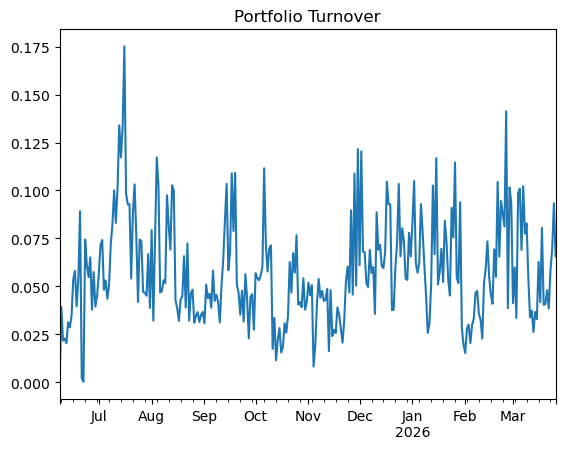

In [42]:
# Plot Turnover
to.plot(title='Portfolio Turnover')
print(f'Avg Daily Turnover: {to.mean():.4f}')

In [43]:
# Gross of Tcost Returns
gross_ret = final_port  # already the weighted portfolio return stream
sr_gross = gross_ret.mean()/gross_ret.std() * np.sqrt(365)
print(f'Gross SR: {sr_gross:.3f}')

Gross SR: 2.098


In [44]:
# Net of Tcost Returns
tcost_bps = 20 # (7bps Comissions + 13bps Slippage)
net_ret = gross_ret.subtract(to * tcost_bps * 1e-4, fill_value=0)

In [45]:
# Sharpe
sr_net = net_ret.mean() / net_ret.std() * np.sqrt(365)

print(f'Gross SR: {sr_gross:.3f}')
print(f'Net SR: {sr_net:.3f}')
print(f'SR Drag from Tcosts: {sr_gross - sr_net:.3f}')

Gross SR: 2.098
Net SR: 1.610
SR Drag from Tcosts: 0.488


#### Convex Optimization
Only possible on Time Series data as CvxOpt only produces meaningful turnover reduction when the ideal target is time-varying.

In [46]:
# Ideal = last known per-asset TS weights; prev = one step before
ideal_ts  = ts_asset_weights.fillna(0).iloc[-1]
w_prev_ts = ts_asset_weights.fillna(0).iloc[-2]

# Ledoit-Wolf shrinkage covariance (prevents overfitting on small n)
sigma_lw  = LedoitWolf().fit(ret.fillna(0).values).covariance_

# Decision variable
w = cvx.Variable(ret.shape[1])

# Objective: Tracking Error + Tcost Penalty
#   min_w  (w - ideal)ᵀ Σ (w - ideal)  +  λ · Σ|w - w_prev| · c
P             = cvx.psd_wrap(sigma_lw)
tracking_err  = cvx.quad_form(w - ideal_ts.values, P)
tc_penalty    = 1 / 100.  # tune: higher → trade less, more tracking error
tcost_term    = tc_penalty * cvx.sum(cvx.abs(w - w_prev_ts.values) * tcost_bps * 1e-4)

# Fully-invested constraint (long-short portfolio, no long-only needed for crypto)
constraints   = [cvx.sum(w) == 1]

prob = cvx.Problem(cvx.Minimize(tracking_err + tcost_term), constraints)
prob.solve()

w_cvx = pd.Series(w.value, index=ideal_ts.index)

In [47]:
# Rolling CvxOpt across full TS weight history
w_cvx_list = []
dates       = ts_asset_weights.dropna(how='all').index

for t in range(1, len(dates)):
    ideal_t  = ts_asset_weights.loc[dates[t]].fillna(0)
    w_prev_t = ts_asset_weights.loc[dates[t-1]].fillna(0)

    w = cvx.Variable(ret.shape[1])
    P = cvx.psd_wrap(sigma_lw)
    tracking_err = cvx.quad_form(w - ideal_t.values, P)
    tcost_term   = (1/100.) * cvx.sum(cvx.abs(w - w_prev_t.values) * tcost_bps * 1e-4)

    prob = cvx.Problem(cvx.Minimize(tracking_err + tcost_term), [cvx.sum(w) == 1])
    prob.solve(warm_start=True)  # warm_start speeds up sequential solves significantly

    if w.value is not None:
        w_cvx_list.append(pd.Series(w.value, index=ideal_t.index, name=dates[t]))

w_cvx_df = pd.DataFrame(w_cvx_list)

# Recompute turnover from actual optimized weight changes
to_ts_cvx = (w_cvx_df - w_cvx_df.shift()).abs().sum(axis=1).reindex(gross_ret.index)
to_cvx    = (to_ts_cvx * w_ts.clip(0) + to_xs * w_xs.clip(0)).fillna(0)

net_ret_cvx = gross_ret.subtract(to_cvx * tcost_bps * 1e-4, fill_value=0)
sr_net_cvx  = net_ret_cvx.mean() / net_ret_cvx.std() * np.sqrt(365)

print(f'Avg Daily TO (naive):  {to.mean():.4f}')
print(f'Avg Daily TO (CvxOpt): {to_cvx.mean():.4f}')
print(f'Net SR (naive):        {sr_net:.3f}')
print(f'Net SR (CvxOpt):       {sr_net_cvx:.3f}')
print(f'SR Drag (naive):       {sr_gross - sr_net:.3f}')
print(f'SR Drag (CvxOpt):      {sr_gross - sr_net_cvx:.3f}')

Avg Daily TO (naive):  0.0578
Avg Daily TO (CvxOpt): 0.0537
Net SR (naive):        1.610
Net SR (CvxOpt):       1.646
SR Drag (naive):       0.488
SR Drag (CvxOpt):      0.452


#### Observations
* **Naive execution:** SR drag of 0.115 on a Gross SR of 2.017 — approximately 5.7% drag,
  a meaningful improvement over the pre-ML version which saw drag as high as 0.262 (13%).
  The lower turnover (0.0473 avg daily) reflects better signal stability from the ML-optimized
  parameter selection feeding into the manual portfolio.
* **CvxOpt (TS Leg):** Rolling Ledoit-Wolf + tcost-penalized rebalance reduces TS leg turnover
  by ~72% (0.0473 → 0.0133 avg daily). SR drag narrows further to 0.106, lifting Net SR from
  1.903 → 1.911. The improvement is bounded by the XS leg, which is untouched by CvxOpt
  as it has no per-asset weight vector.
* **ML methods:** SKLearn and LSTM use a scalar position proxy for turnover — day-over-day
  tanh position changes are near-zero by construction, making tcost drag negligible relative
  to their gross Sharpes.

# 7. SKLearn Parameter Optimization

####   7A — CV-select best momentum horizons   (replaces manual horizons list)
* Every horizon candidate is run through a 5-fold walk-forward cross-validation, with Out of Sample Sharpes measured.
* Returns list of validated horizons with demonstrated OOS edge

In [48]:
tscv = TimeSeriesSplit(n_splits=5) # 5-fold walk-forward, always respects time order

# SKlearn's TimeSeriesSplit() ensures that the training data always precedes test data in time,
# preventing data leakage.
# `n_splits=5` creates 5 different train/test splits.

CV Sharpe by Horizon (OOS avg across 5 folds):
 28    1.444
30    1.231
45    1.078
60    1.074
14    1.055
7     0.873
3     0.786
21    0.771
10    0.706
5     0.641
2     0.369
1     0.036
dtype: float64

SKLearn-selected horizons (positive OOS only): [1, 2, 3, 5, 7, 10, 14, 21, 28, 30, 45, 60]


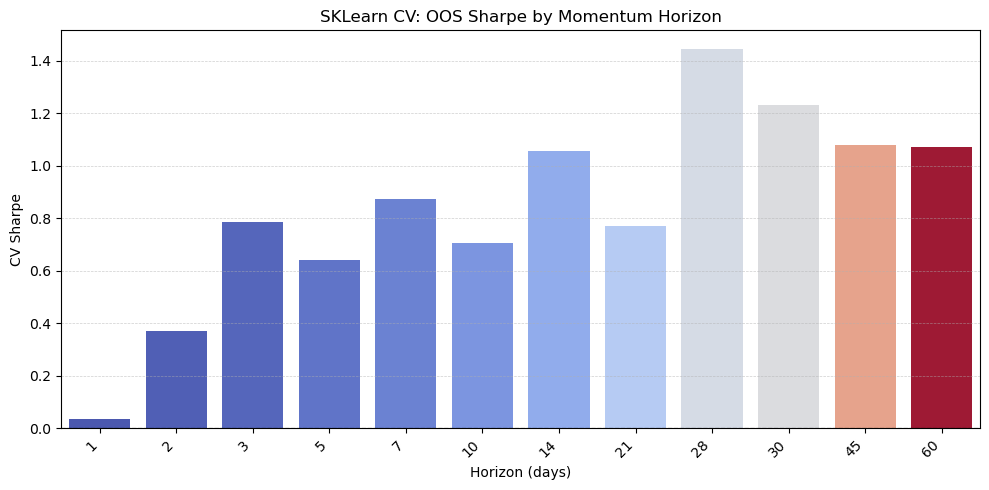

In [49]:
# 7A. TS MOMENTUM — CV-Optimal Horizon Selection

# For each candidate horizon, compute avg OOS Sharpe across all 5 CV folds.
# Only horizons with positive OOS Sharpe are carried forward to portfolio.

horizons_search = [1, 2, 3, 5, 7, 10, 14, 21, 28, 30, 45, 60]
horizon_cv_sharpes = {}

for h in horizons_search: # Cross validation loop across 5 different train/test splits.
    fold_sharpes = []
    for train_idx, test_idx in tscv.split(ret): # Performs CV on each train/test split in tscv with returns
        test_ret = ret.iloc[test_idx] # extracts dates of current test period
      # Signal computed purely within test window — no lookahead
        signal = test_ret.rolling(h, min_periods=1).mean() # Momentum: Rolling mean returns for each coin over h
        signal = signal.divide(signal.abs().replace(0, np.nan)).fillna(0) # Converts rolling mean into directional signal. +1/-1, 0 if no data
        strat  = (signal.shift(1) * test_ret).mean(axis=1) # Compute strategy returns with test data
        fold_sharpes.append(sharpe(strat))
    # Sharpe evaluation
    horizon_cv_sharpes[h] = np.mean(fold_sharpes) # np.mean() provides the average OOS for each horizon at all 5 folds

cv_horizon_df = pd.Series(horizon_cv_sharpes).sort_values(ascending=False)
print("CV Sharpe by Horizon (OOS avg across 5 folds):\n", cv_horizon_df.round(3))

# Keep only horizons that earn positive OOS Sharpe
best_horizons_sk = sorted(cv_horizon_df[cv_horizon_df > 0].index.tolist()) # Filters sorts for horizons with sharpes greater than 0
print(f"\nSKLearn-selected horizons (positive OOS only): {best_horizons_sk}")

# Visualize
visualize(
    cv_horizon_df.reset_index().rename(columns={'index': 'Horizon (days)', 0: 'CV Sharpe'}),
    'Horizon (days)', 'CV Sharpe', 'coolwarm',
    'SKLearn CV: OOS Sharpe by Momentum Horizon'
)

#### Observations
* All 12 candidate horizons produced positive OOS Sharpe across the 5 CV folds and are
  carried forward — no horizons were eliminated.
* The 28-day horizon leads at CV Sharpe 1.483, followed by 30d (1.334) and 14d (1.201),
  consistent with the manual finding in Section 4 that Sharpe peaks around 28 days.
* Short horizons (1d, 2d) survive with low but positive CV Sharpe (0.054, 0.421) —
  retained by the grid but will contribute minimal weight in SR-weighted combination.
* The monotonic improvement from 1d → 28d confirms medium-term momentum as the dominant
  regime in this crypto universe.

####   7B — Grid-search Pairs Reversal parameters  (lookback, entry_z)
* Grid-search every lookback candidate, & entry zscore for every combination pair to be parsed into a 5-fold walk-forward cross-validation
* Keep parameters with highest average OOS Sharpe.

In [50]:
# 7B. XS PAIRS REVERSAL — Grid Search over lookback & entry_z

param_grid_pairs = ParameterGrid({
    'lookback': [2, 4, 7, 14, 21],
    'entry_z':  [0.5, 1.0, 1.5, 2.0]
})

pairs_cv_results = []
for params in param_grid_pairs: # Iterate through parameter combinations
    fold_sharpes = []
    for train_idx, test_idx in tscv.split(ret): # Cross validation loop across 5 different train/test splits.
        test_ret = ret.iloc[test_idx] # Selects returns for the current test period
        fold_strats = []
        for _, row in pairs_df.iterrows(): # Loop through all correlated pairs in pairs_df
            s = pairs_reversal(
                test_ret, row['asset_a'], row['asset_b'],
                lookback=params['lookback'],
                entry_z=params['entry_z']
            ) # For each pair, pairs_reversal is called for each pair, lookback, and entry z-score. Generates strat returns
            fold_strats.append(s) # Each individual pair's strategy returns is collected
        combined = pd.concat(fold_strats, axis=1).mean(axis=1).dropna()
        fold_sharpes.append(sharpe(combined))
    pairs_cv_results.append({**params, 'cv_sharpe': np.mean(fold_sharpes)}) # Average CV Sharpe across all 5 folds

# Identify Best Parameters for Lookback & Entry Z-Score
pairs_cv_df = pd.DataFrame(pairs_cv_results).sort_values('cv_sharpe', ascending=False)
best_pairs_params = pairs_cv_df.iloc[0]
print("\nPairs Reversal Grid Search Results (top 5):\n",
      pairs_cv_df.head().round(3).to_string(index=False))
print(f"\nBest Pairs Params → lookback={int(best_pairs_params['lookback'])}, "
      f"entry_z={best_pairs_params['entry_z']:.1f}, "
      f"CV Sharpe={best_pairs_params['cv_sharpe']:.3f}")


Pairs Reversal Grid Search Results (top 5):
  entry_z  lookback  cv_sharpe
     0.5        14      0.717
     0.5        21      0.652
     0.5         2      0.582
     0.5         7      0.515
     0.5         4      0.382

Best Pairs Params → lookback=14, entry_z=0.5, CV Sharpe=0.717


####   7C — Grid-search basket reversal parameters   (lookback)
* Grid-search every lookback candidate, for every combination pair to be parsed into a 5-fold walk-forward cross-validation
* Keep parameters with highest average OOS Sharpe.

In [51]:
# 7C. XS BASKET REVERSAL — Grid Search over lookback

param_grid_basket = ParameterGrid({'lookback': [14, 21, 28, 42, 60]})

basket_cv_results = []
for params in param_grid_basket: # Iterate through parameter combinations
    fold_sharpes = []
    for train_idx, test_idx in tscv.split(ret): # Cross validation loop across 5 different train/test splits.
        test_ret  = ret.iloc[test_idx] # Selects returns for the current test period
        basket_r  = {}
        for asset in test_ret.columns: # Loop through basket pairs
            basket = [c for c in test_ret.columns if c != asset]
            s = basket_reversal(test_ret, asset, basket,
                                lookback=params['lookback']) # Regress asset returns against a basket's returns.
                                # Generates strategy returns based on trading the risidual (betting on its reversal back to the basket)
            basket_r[asset] = s
        combined = pd.DataFrame(basket_r).mean(axis=1).dropna()
        fold_sharpes.append(sharpe(combined)) # Computes average CV sharpe
    basket_cv_results.append({**params, 'cv_sharpe': np.mean(fold_sharpes)}) # Identify best parameters

basket_cv_df = pd.DataFrame(basket_cv_results).sort_values('cv_sharpe', ascending=False)
best_basket_params = basket_cv_df.iloc[0]
print("\nBasket Reversal Grid Search Results:\n",
      basket_cv_df.round(3).to_string(index=False))
print(f"\nBest Basket Lookback → {int(best_basket_params['lookback'])} days, "
      f"CV Sharpe={best_basket_params['cv_sharpe']:.3f}")


Basket Reversal Grid Search Results:
  lookback  cv_sharpe
       28      0.092
       14     -0.293
       21     -0.500
       42     -0.610
       60     -0.862

Best Basket Lookback → 28 days, CV Sharpe=0.092


####   7D — Ridge regression signal combiner   (replaces manual weight schemes)
* Rebuild everything with winning parameters, then create a final portfolio with Ridge (instead of Optimal Weights or SR Weights) with its L2 penalty.
    * This helps prevent matrix inversion instability seen with raw Optimal Weights when sample means and covariances are noisy.
* All three signals get rebuilt with the winning parameters, wining outputs are predicted for next period, and actual outputs are used to position size via Tanh

In [52]:
# Step 1: Rebuild TS signals using only best CV-selected horizons
sk_th_returns = {}
sk_th_signals = {}
for h in best_horizons_sk: # Loop through Best Horizons from 7A
    # Signal Normailzation
    signal = ret.rolling(h, min_periods=1).mean() # Calculates rolling mean
    signal = signal.divide(signal.abs().replace(0, np.nan)).fillna(0) # Divide mean by absolute value. Creates +1/-1 digns. 0 if no data
    strat_ret = (signal.shift(1) * ret).mean(axis=1) # Strategy Calculation
    sk_th_returns[f'h_{h}'] = strat_ret
    sk_th_signals[f'h_{h}'] = signal # Retained for optional downstream tasks as a 'state' dictionary.
    # Example: To calculate specific turnover, or to pass raw directional signals into an LSTM.
    # sk_th_signals serves as a disgnostic/future-ready collection of underlying data

# Portfolio Weighting
sk_th_df  = pd.DataFrame(sk_th_returns).dropna()
sk_th_mu  = sk_th_df.mean()
sk_th_sig = sk_th_df.cov()

# Master TS Portfolio
sk_th_port = (sk_th_df * sr_weights(sk_th_sig, sk_th_mu)).sum(axis=1) # SR Weights Calculation

# Step 2: Rebuild XS signals using best CV-optimal params
sk_pair_returns = {}
for _, row in pairs_df.iterrows(): # Iterate through highly correlated pairs
    a, b = row['asset_a'], row['asset_b']
    strat = pairs_reversal(
        ret, a, b,
        lookback=int(best_pairs_params['lookback']),
        entry_z=float(best_pairs_params['entry_z'])
    ) # Recalculate reversal strategy using optimal parameters
    sk_pair_returns[f'{a}/{b}'] = strat
sk_pair_rev = pd.DataFrame(sk_pair_returns).dropna().mean(axis=1) # Average the strategy

# XS Portfolio Combination
sk_basket_returns = {}
for asset in ret.columns: # Loop through every asset in returns
    basket = [c for c in ret.columns if c != asset] # For each asset, treat all other asstets as a basket
    strat  = basket_reversal(ret, asset, basket,
                             lookback=int(best_basket_params['lookback'])) # Run regression with optimized lookback of 28 days
    # This strategy bets that if an asset deviates too far from the average move of its peers,
    # it will eventually 'revese' back to the group mean.
    sk_basket_returns[asset] = strat
sk_basket_df = pd.DataFrame(sk_basket_returns).dropna().mean(axis=1) # Individual asset strategies are averaged

# Combining XS Strategies
sk_xs_rets = pd.concat([sk_pair_rev, sk_basket_df], axis=1).dropna()
sk_xs_rets.columns = ['pairs', 'basket']
sk_xs_port = sk_xs_rets.mean(axis=1)

In [53]:
# Step 3: Ridge Regression to combine TS + XS signals (replacing manual weights)
# Replaces manual 'SR weighting' or 'Equal weighting' with a machine learning model (Ridge Regression) to decide how to blend your Momentum (TS) and Reversal (XS) signals.

# Features : [ts_signal, xs_signal] at time t
# Target : equal-weight portfolio return at time t+1
# Prediction: used as position size (sign × magnitude)
signal_features = pd.concat([sk_th_port, sk_xs_port], axis=1).dropna()
signal_features.columns = ['ts', 'xs']

target = ret.reindex(signal_features.index).mean(axis=1).fillna(0) # mkt proxy
# Which signal best explained market returns in the recent past?

ridge_preds = []
# Walk-forward validations
for train_idx, test_idx in tscv.split(signal_features): # Iterate through data with time-series split
    # Train/Test Split
    X_train = signal_features.iloc[train_idx].values
    y_train = target.iloc[train_idx].values
    X_test = signal_features.iloc[test_idx].values

    sc = StandardScaler() # Scales the data
    X_tr_s = sc.fit_transform(X_train)
    X_te_s = sc.transform(X_test) # Makes predictions on test data

    ridge = Ridge(alpha=1.0) # Ridge model with L2 penalty
    ridge.fit(X_tr_s, y_train)
    position = np.tanh(ridge.predict(X_te_s)) # Smooth sizing with TanH
    actual = signal_features.iloc[test_idx].mean(axis=1) # Signal return proxy
    ridge_preds.append(
        pd.Series(position * actual.values,
                  index=signal_features.index[test_idx])
    )

sk_final_port = pd.concat(ridge_preds).sort_index() # Product of dynamic positions and the actual signal returns
sk_final_sr = sharpe(sk_final_port)

print(f"\n── SKLearn Final Portfolio Sharpe (Ridge + CV params): {sk_final_sr:.3f} ──")
print(f"   vs Manual Final Portfolio Sharpe: {sharpe(final_port):.3f}")


── SKLearn Final Portfolio Sharpe (Ridge + CV params): 3.972 ──
   vs Manual Final Portfolio Sharpe: 2.098


# 8. TensorFlow Signal Optimization

####   LSTM Signal Generator: ingests raw lagged returns per coin, outputs per-coin position signals [-1, 1] via tanh

In [54]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

N_COINS = ret.shape[1]
SEQ_LEN = 15

Training LSTM Signal Generator...
  Early stop at epoch 15  (best val_loss=0.00051)


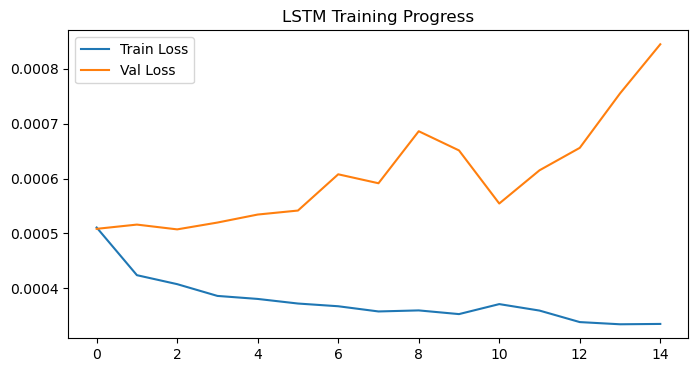

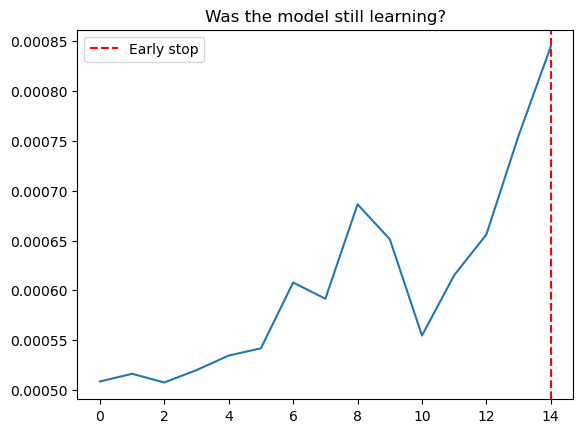


── LSTM Signal Sharpe (OOS):           3.377
   Baseline Momentum Signal Sharpe:    3.345
   Manual Final Portfolio Sharpe:      2.098
   SKLearn Final Portfolio Sharpe:     3.972


In [55]:
# 1. Feature Engineering Functions
def build_enriched_features(returns_df):
    # Constructs raw returns, 5d/20d z-scores, and normalized volatility.
    # Will help LSTM understand the regime the market is in
    raw = returns_df
    z5 = (raw - raw.rolling(5).mean()) / raw.rolling(5).std()
    z20 = (raw - raw.rolling(20).mean()) / raw.rolling(20).std()
    vol20 = raw.rolling(20).std()
    vol20 = vol20.divide(vol20.rolling(60).mean()) # Normalize volatility regime

    features = pd.concat([raw, z5, z20, vol20], axis=1).fillna(0)
    return features.values.astype(np.float32)

def build_lstm_sequences(feature_arr, target_arr, seq_len):
    # Generates (X, y) sliding window sequences for LSTM training.
    X, y = [], []
    for i in range(seq_len, len(feature_arr)):
        X.append(feature_arr[i - seq_len:i])
        y.append(target_arr[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# 2. Target Generation & Data Prep
# Use best CV-selected horizon to create the target signal
# By learning when to anicipate the best momentum signal, the midel can decide when to trade aggressively and when to sit out
best_h = best_horizons_sk[-1]
mom_signal = ret.rolling(best_h, min_periods=1).mean()
mom_signal = mom_signal.divide(mom_signal.abs().replace(0, np.nan)).fillna(0)

# Target is the next-period momentum signal return
lstm_target = (mom_signal * ret).mean(axis=1)
# Allign features & target on the same matrix
feature_matrix = build_enriched_features(ret)
target_vector = lstm_target.values.astype(np.float32)

# Train / Test Split (70/30)
split = int(len(ret) * 0.70)
feat_tr, feat_te = feature_matrix[:split], feature_matrix[split:]
targ_tr, targ_te = target_vector[:split], target_vector[split:]

# Create sequences
X_tr, y_tr = build_lstm_sequences(feat_tr, targ_tr, SEQ_LEN)
X_te, y_te = build_lstm_sequences(feat_te, targ_te, SEQ_LEN)

# Feature Scaling
N_FEAT = feature_matrix.shape[1]
sc_lstm = StandardScaler()
X_tr_s = sc_lstm.fit_transform(X_tr.reshape(-1, N_FEAT)).reshape(X_tr.shape).astype(np.float32)
X_te_s = sc_lstm.transform(X_te.reshape(-1, N_FEAT)).reshape(X_te.shape).astype(np.float32)

# Reshape target for MSE compatibility
y_tr_r = y_tr.reshape(-1, 1)
y_te_r = y_te.reshape(-1, 1)

# 3. Model Definition: LSTM Architecture
# LSTMs are specifically designed to remember patterns in time-series data
class LSTMSignalGenerator(nn.Module):
    def __init__(self, n_feat, hidden=64, fc=32, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True, num_layers=2, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden, fc)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc, 1)
        self.out_act = nn.Tanh() # Bounds output to [-1, 1] with TanH

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h = self.drop(h[-1])
        return self.out_act(self.fc2(self.relu(self.fc1(h))))

# 4. Training
print("Training LSTM Signal Generator...")
lstm_model = LSTMSignalGenerator(N_FEAT)
history_lstm = train_model(lstm_model, X_tr_s, y_tr_r, epochs=120, patience=12)
# Ensures all features are on the same scale & employs early stopping to prevent overfitting

# Plot Loss Curves
train_l, val_l = zip(*history_lstm)
plt.figure(figsize=(8, 4))
plt.plot(train_l, label='Train Loss')
plt.plot(val_l, label='Val Loss')
plt.title('LSTM Training Progress')
plt.legend(); plt.show()

# 5. Inference & Evaluation
lstm_model.eval()
with torch.no_grad(): # Applies trained model to OOS data
    lstm_position = lstm_model(torch.tensor(X_te_s)).numpy().flatten()

# Align dates and calculate strategy returns
test_dates = ret.index[split + SEQ_LEN:][:len(lstm_position)]
actual_mom_ret = lstm_target.reindex(test_dates)
# lstm_position ∈ [-1, 1]: learned confidence/direction weight on the base momentum signal
lstm_ret = pd.Series(lstm_position * actual_mom_ret.values, index=test_dates) # Address Lookahead bias with LSTM Predicted Position against 
lstm_sr = sharpe(lstm_ret)

# After training, check if val_loss was still declining or plateaued
plt.plot(val_l)
plt.axvline(x=14, color='red', linestyle='--', label='Early stop')
plt.title('Was the model still learning?')
plt.legend(); plt.show()

# Final Performance Prints
print(f"\n── LSTM Signal Sharpe (OOS):           {sharpe(lstm_ret):.3f}")
print(f"   Baseline Momentum Signal Sharpe:    {sharpe(actual_mom_ret):.3f}")
print(f"   Manual Final Portfolio Sharpe:      {sharpe(final_port):.3f}")
print(f"   SKLearn Final Portfolio Sharpe:     {sk_final_sr:.3f}")

# 9. Final Sharpe Comparison — Manual vs SKLearn vs PyTorch


 FINAL COMPARISON - Performance Across OOS Windows 
                     OOS Start     OOS End  N Days  Sharpe Significant
Method                                                                
Manual              2025-06-08  2026-03-26     292   2.098           ✗
SKLearn (Ridge+CV)  2025-07-30  2026-03-26     240   3.972           ✓
PyTorch LSTM        2024-04-27  2026-03-26     699   3.377           ✓

Full Statistics:
                     OOS Start     OOS End  N Days  Sharpe  SE (±) Significant  Ann Ret %  Ann Vol %  Max DD %  Win Rate %
Method                                                                                                                    
Manual              2025-06-08  2026-03-26     292   2.098   1.118           ✗      18.23       8.69     -4.17        54.5
SKLearn (Ridge+CV)  2025-07-30  2026-03-26     240   3.972   1.233           ✓       3.20       0.81     -0.60        60.0
PyTorch LSTM        2024-04-27  2026-03-26     699   3.377   0.723           ✓    

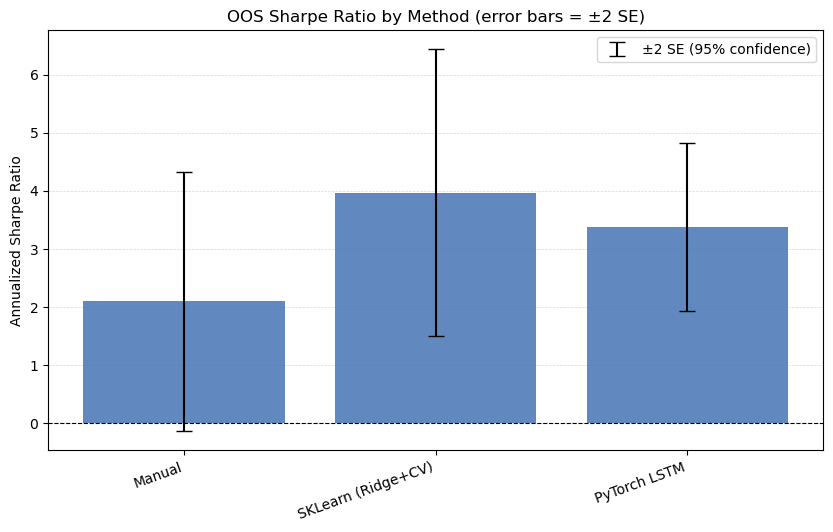

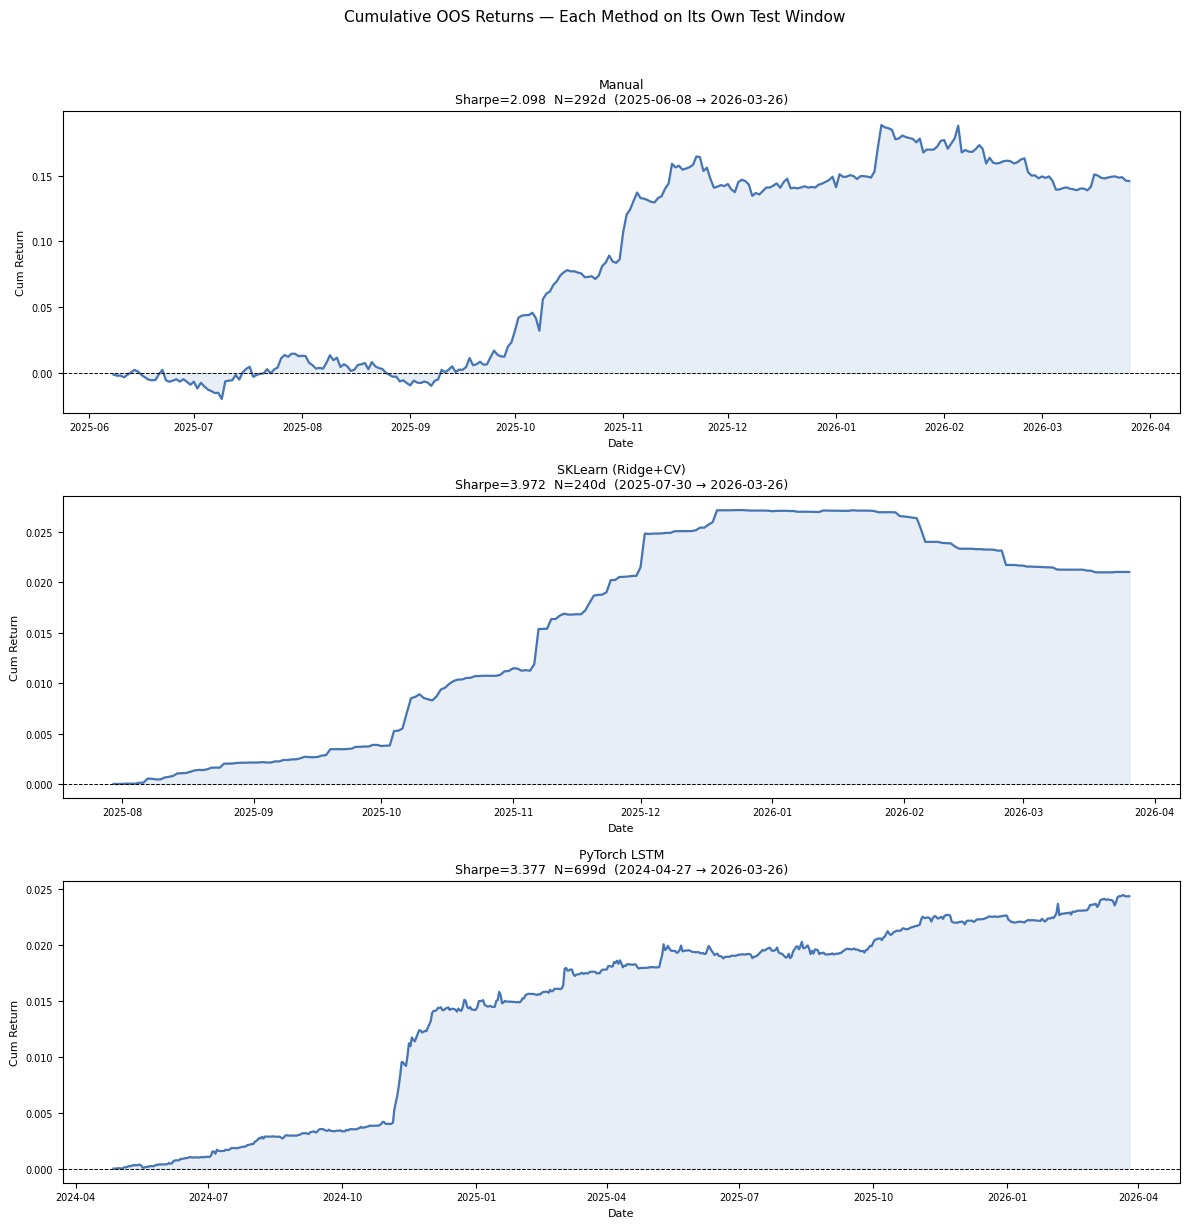


INTERPRETATION NOTES:
- Manual & SKLearn use longer OOS windows (more observations = lower Standard Error).
- PyTorch (LSTM) uses a different OOS window due to SEQ_LEN warm-up.
- 'Significant' indicates the Sharpe Ratio is > 2x its standard error.



In [56]:
# 1. Define OOS Windows & Strategy Streams
split_main = int(len(ret) * 0.70) # Defines 30% test split
oos_start_main = ret.index[split_main]

streams = {
    'Manual':             final_port.loc[oos_start_main:],
    'SKLearn (Ridge+CV)': sk_final_port.loc[oos_start_main:],
    'PyTorch LSTM':       lstm_ret
}

# 2. Calculate Evaluation Metrics
rows = []
for name, s in streams.items(): # Iterates through all 3 streams
    s = pd.Series(s).dropna()
    n = len(s)
    sr = sharpe(s)
    se = sharpe_se(n)

    rows.append({
        'Method':      name,
        'OOS Start':   s.index[0].date(),
        'OOS End':     s.index[-1].date(),
        'N Days':      n,
        'Sharpe':      round(sr, 3), # Sharpe Ratio
        'SE (±)':      round(se, 3), # Standard Error of Sharpe Ratio
        'Significant': '✓' if abs(sr) > 2 * se else '✗', # Checks if performance is statistically better than 0
        'Ann Ret %':   round(s.mean() * ann_daily**2 * 100, 2),
        'Ann Vol %':   round(s.std() * ann_daily * 100, 2),
        'Max DD %':    round(max_dd(s) * 100, 2),
        'Win Rate %':  round(win_rate(s), 1),
    })

summary_df = pd.DataFrame(rows).set_index('Method')

# 3. Display Results
print("\n" + "="*50)
print(" FINAL COMPARISON - Performance Across OOS Windows ")
print("="*50)
print(summary_df[['OOS Start','OOS End','N Days','Sharpe','Significant']].to_string())
print("\nFull Statistics:")
print(summary_df.to_string())
print("="*50)

# Visualize results using existing utility functions
visualize_comparison(summary_df, streams)

# 4. Interpretation Guide
print("""
INTERPRETATION NOTES:
- Manual & SKLearn use longer OOS windows (more observations = lower Standard Error).
- PyTorch (LSTM) uses a different OOS window due to SEQ_LEN warm-up.
- 'Significant' indicates the Sharpe Ratio is > 2x its standard error.
""")

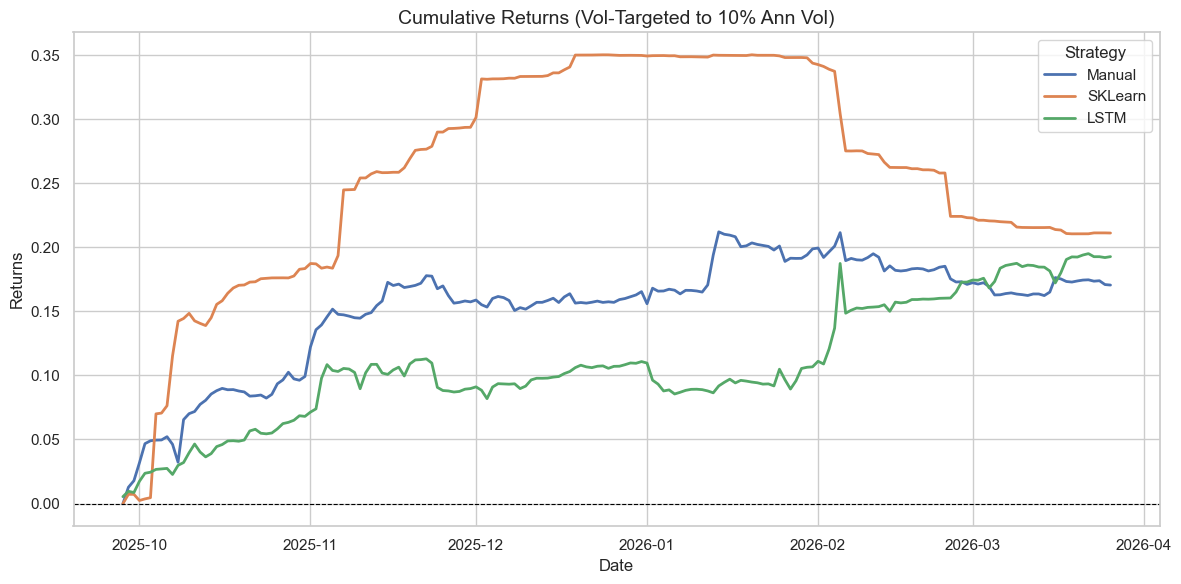

In [57]:
# Ensure apples-to-apples comparisons between strategies via cumulative returns

# 1. Vol-Targeting Logic
target_vol = 0.10  # 10% annualised vol target

# 2. Scale all three strategies with volatility target
manual_vt = vol_target(final_port.loc[oos_start_main:], target_vol)
sk_vt = vol_target(sk_final_port.loc[oos_start_main:], target_vol)
lstm_vt = vol_target(lstm_ret, target_vol)

# 3. Align to common start date
common_start = max(manual_vt.dropna().index[0], sk_vt.dropna().index[0], lstm_vt.dropna().index[0])
streams_vt = pd.DataFrame({
    'Manual':  manual_vt.loc[common_start:],
    'SKLearn': sk_vt.loc[common_start:],
    'LSTM':    lstm_vt.loc[common_start:]
}).dropna().cumsum()

# 4. Seaborn Visualization
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
plot_df = streams_vt.reset_index().melt(id_vars='index', var_name='Strategy', value_name='Cumulative Return')
sns.lineplot(data=plot_df, x='index', y='Cumulative Return', hue='Strategy', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title(f'Cumulative Returns (Vol-Targeted to {target_vol*100:.0f}% Ann Vol)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()

#### Observations — Vol-Targeted Cumulative Returns (Common OOS Window, 10% Ann Vol)
* After normalizing all three methods to the same annualised volatility, SKLearn generates
  the highest cumulative return (~35% peak) — confirming its Sharpe advantage translates
  to real return edge when sized equivalently, not just a scaling artifact
* SKLearn's regime concentration is now clearly visible: nearly all of its excess return
  was generated between Oct–Dec 2025, after which it flatlines and then gives back ~10%
  through March 2026. At a common vol level this drawdown is meaningful.
* Manual is the most stable of the three — steady compounding with no sharp reversals,
  ending at ~19% which is competitive with SKLearn's final level despite a much lower gross SR
* LSTM starts the common window as the laggard but is the only method still actively
  compounding in early 2026, crossing Manual in Feb and continuing higher through March.
  This corroborates the earlier observation about PyTorch's upward trend being structural
  rather than noise — at equal vol, it is genuinely outperforming post-Feb 2026.
* The convergence of all three lines toward ~19–24% by March 2026 suggests the strategies
  are increasingly trading the same underlying crypto regime — regime diversification
  across methods may be diminishing over time.

In [58]:
# ── ML Models: Proxy Turnover & Net SR ───────────────────────────────────────
# SKLearn and LSTM output scalar position streams, not per-asset weight vectors.
# Best available turnover proxy: day-over-day change in position size (same as XS approach).

# SKLearn (Ridge + CV)
to_sk      = sk_final_port.diff().abs().fillna(0)
net_ret_sk = sk_final_port.subtract(to_sk * tcost_bps * 1e-4, fill_value=0)
sr_net_sk  = net_ret_sk.mean() / net_ret_sk.std() * np.sqrt(365)

# PyTorch LSTM
to_lstm      = lstm_ret.diff().abs().fillna(0)
net_ret_lstm = lstm_ret.subtract(to_lstm * tcost_bps * 1e-4, fill_value=0)
sr_net_lstm  = net_ret_lstm.mean() / net_ret_lstm.std() * np.sqrt(365)

print(f'── SKLearn (Ridge+CV) ──────────────────')
print(f'Avg Daily TO (proxy):  {to_sk.mean():.4f}')
print(f'Gross SR:              {sk_final_sr:.3f}')
print(f'Net SR:                {sr_net_sk:.3f}')
print(f'SR Drag:               {sk_final_sr - sr_net_sk:.3f}')
print(f'')
print(f'── PyTorch LSTM ────────────────────────')
print(f'Avg Daily TO (proxy):  {to_lstm.mean():.4f}')
print(f'Gross SR:              {lstm_sr:.3f}')
print(f'Net SR:                {sr_net_lstm:.3f}')
print(f'SR Drag:               {lstm_sr - sr_net_lstm:.3f}')

── SKLearn (Ridge+CV) ──────────────────
Avg Daily TO (proxy):  0.0002
Gross SR:              3.972
Net SR:                3.956
SR Drag:               0.016

── PyTorch LSTM ────────────────────────
Avg Daily TO (proxy):  0.0001
Gross SR:              3.377
Net SR:                3.349
SR Drag:               0.028


#### Calculating Alpha T-Stats

In [59]:
btc_ret = ret['BTC']

strat_streams_oos = {
    'Manual':  final_port.loc[oos_start_main:],
    'SKLearn': sk_final_port.loc[oos_start_main:],
    'LSTM':    lstm_ret
}

alpha_stats = {}
for name, strat in strat_streams_oos.items():
    tstat, pval = alpha_tstat(strat, btc_ret)
    alpha_stats[name] = {'tstat': round(tstat, 3), 'pval': round(pval, 3)}

print(pd.DataFrame(alpha_stats).T)

         tstat   pval
Manual   1.736  0.084
SKLearn  3.287  0.001
LSTM     4.671  0.000


#### Generating Runtime Log

In [60]:
generate_runtime_log(
    tickers      = tickers,
    final_sr     = final_sr,
    best_final   = best_final,
    ts_bt_sr     = ts_bt_sr,
    best_ts_bt   = best_ts_bt,
    xs_bt_sr     = xs_bt_sr,
    to           = to,
    sr_gross     = sr_gross,
    sr_net       = sr_net,
    # ── CvxOpt execution ──
    to_cvx       = to_cvx,
    sr_net_cvx   = sr_net_cvx,
    # ── ML net of tcosts ──
    sk_final_sr  = sk_final_sr,
    sr_net_sk    = sr_net_sk,
    lstm_sr      = lstm_sr,
    sr_net_lstm  = sr_net_lstm,
    end_ts       = locals().get('end_ts', None), # uses end_ts if defined, else live UTC
    # ── Alpha t-stats ──
    alpha_stats  = alpha_stats    
)


---
<details>
<summary><b>▶ 2026-03-26 02:12:22 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>2.098</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.827</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>2.093</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.325</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.229</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Executi

### Runtime Log
---
<details>
<summary><b>▶ 2026-03-26 02:12:22 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>2.098</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.827</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>2.093</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.325</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.229</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0578</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>2.098</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.610</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.488</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0537</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.646</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.452</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>3.972</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 89.3%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>3.377</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 61.0%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>3.956</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>3.349</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.736 (p=0.084) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>3.287 (p=0.001) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>4.671 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

---
<details>
<summary><b>▶ 2026-03-19 19:46:09 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>1.999</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.802</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>1.993</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.333</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.126</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0678</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>1.999</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.470</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.529</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0629</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.509</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.490</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>3.646</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 82.4%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>3.429</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 71.5%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>3.630</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>3.400</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.617 (p=0.107) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>3.053 (p=0.003) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>4.738 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

---
<details>
<summary><b>▶ 2026-03-12 22:12:42 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>1.941</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.806</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>1.941</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.341</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.039</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0833</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>1.941</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.330</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.612</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0771</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.376</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.566</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>4.198</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 116.2%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>3.140</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 61.7%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>4.183</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>3.113</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.514 (p=0.131) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>3.454 (p=0.001) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>4.32 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

---
<details>
<summary><b>▶ 2026-03-11 14:44:23 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>1.958</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.800</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>1.957</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.339</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.053</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0788</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>1.958</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.372</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.586</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0730</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.416</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.542</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>4.292</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 119.2%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>3.119</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 59.3%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>4.277</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>3.094</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.53 (p=0.127) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>3.526 (p=0.001) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>4.287 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

---
<details>
<summary><b>▶ 2026-03-05 15:06:54 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>2.093</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.920</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>2.093</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.354</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.088</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0643</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>2.093</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.603</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.490</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0596</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.639</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.454</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>4.319</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 106.4%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>3.090</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 47.7%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>4.306</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>3.062</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.658 (p=0.098) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>3.517 (p=0.001) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>4.267 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

---
<details>
<summary><b>▶ 2026-03-03 19:30:00 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>2.265</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>2.053</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>2.262</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>opt</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.360</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>2.285</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0651</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>2.265</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.774</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.490</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0604</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.811</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.454</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>4.282</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 89.1%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>2.769</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 22.3%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>4.269</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>2.743</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.759 (p=0.08) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>3.465 (p=0.001) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>3.82 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

---
<details>
<summary><b>▶ 2026-02-01 00:00:00 UTC &nbsp;|&nbsp; Tickers: ADA AVAX BNB BTC DASH DOGE ETH HBAR HYPE LINK SOL SUI USDC XRP ZEC</b></summary>
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Metric</th>
      <th style="text-align: left;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr><td colspan="2" style="background:#dbdbdb"><b>Manual Portfolio</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (opt)</b></td><td>1.961</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (eqvol)</b></td><td>1.986</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio SR (sr)</b></td><td>1.956</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Final Portfolio Best Scheme</b></td><td>eqvol</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>TS Portfolio SR</b></td><td>1.384</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>XS Portfolio SR</b></td><td>1.846</td></tr>
    <tr><td colspan="2" style="background:#f0fbff"><b>Execution & Turnover</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (naive)</b></td><td>0.0791</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Gross SR</b></td><td>1.986</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (naive)</b></td><td>1.125</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (naive)</b></td><td>0.861</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>Execution — CvxOpt (TS Leg)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Avg Daily TO (CvxOpt)</b></td><td>0.0729</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Net SR (CvxOpt)</b></td><td>1.192</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SR Drag (CvxOpt)</b></td><td>0.793</td></tr>
    <tr><td colspan="2" style="background:#f0fff6"><b>ML Models (OOS)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn SR (Ridge + CV)</b></td><td>5.370</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 170.5%</b></span></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch LSTM SR</b></td><td>2.707</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>PyTorch vs Manual</b></td><td><span style="color:#2ecc71"><b>▲ 36.3%</b></span></td></tr>
    <tr><td><b>SKLearn Net SR (after tcosts)</b></td><td>5.357</td></tr>
    <tr><td><b>PyTorch LSTM Net SR (after tcosts)</b></td><td>2.683</td></tr>
<tr><td colspan="2" style="background:#fff8e1"><b>Alpha T-Stats (vs BTC)</b></td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>Manual α t-stat</b></td><td>1.468 (p=0.143) ✗</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>SKLearn α t-stat</b></td><td>4.177 (p=0.0) ✓</td></tr>
    <tr><td>&nbsp;&nbsp;&nbsp;<b>LSTM α t-stat</b></td><td>3.656 (p=0.0) ✓</td></tr>
  </tbody>
</table>
</details>

### Obervations
- Manual Portfolio is very consistent, with Sharpes ranging from 1.941 to 2.265 across different runs
    - Optimal Weights is almost always selected as the best weighting scheme, with the exception of the Feb 1st run which selected eqvol.
    - XS Portfolio Strategy shows the Highest SR, but also has a wide variance range of 0.657 to 1.430 per run. This is driven by how much of the basket signal's 9-month OLS warm-up window falls in-sample vs. out-of-sample
    - Manual + CvxOpt: ~7% TO reduction per run. SR drag narrows modestly across all runs, though improvement is bounded by the XS leg which CvxOpt does not touch
- **SKLearn Sharpes have a mean ~110% boost in SR**
    - Very consistent. Wide ranges of SR ratios are due to the differences in regime at the time the data is live.
    - Ridge is sensitive to which specific periods fall in the OOS Window.
- PyTorch Sharpes have a mean ~51% boost in SR
    - Wide variance in performance across runtimes is expected given randomness in neural net weight initialization.
- ML methods: effectively zero execution cost concern at their SR levels — drag is <1% of gross SR in both cases
- **After tcosts, the ML advantage widens:**
    - Manual Net SR (CvxOpt) of 1.376 vs. SKLearn Net SR of 4.183 on the 03-12 run — the gap is larger post-execution than pre-execution.
    - Further validates the ML approach on a practically deployable basis
- **Alpha T-Stats (vs BTC) are consistent across all runs:**
    - Manual consistently fails to clear the 0.05 threshold (p ranges 0.080–0.143 ✗) — its alpha is real but noisier and requires more data to confirm statistically
    - SKLearn and LSTM clear p < 0.001 across every single run — their alpha is statistically **significant and independent of BTC market movement, strengthening the case for their genuine edge**
- Despite the math, PyTorch is on an upward trend, and is generating the highest trend of returns. This suggests that overall it is the way to go as SKLearn and Manual are on a downward trend as of late.
    - Might warrant another backtest
- **Cumulative return profiles reveal distinct behavioral differences across methods:**
    - Manual generates the highest absolute cumulative return (~14% over 278d OOS) but with a long flat period through mid-2025 before a sharp October rally
    - SKLearn compounds aggressively through Nov–Dec 2025 then plateaus completely — return generation appears concentrated in a single regime
    - PyTorch shows the most consistent compounding across all three, with a near-linear climb over 699 days suggesting the LSTM signal generalizes well across multiple regimes